In [73]:
import math
import numpy as np
from coppeliasim_zmqremoteapi_client import RemoteAPIClient
import time

class HokuyoSensorSim(object):
    _sim = None
    _base_name = ""
    _vision_sensor_name_template = "{}/sensor{}"
    _base_obj = None
    _is_range_data = False
    
    _angle_min = -120*math.pi/180
    _angle_max = 120*math.pi/180
    _angle_increment = (240/684)*math.pi/180  # angle: 240 deg, pts: 684

    def __init__(self, sim, base_name, is_range_data=True):
        self._sim = sim
        self._base_name = base_name
        self._is_range_data = is_range_data

        if "fastHokuyo" not in base_name:
            raise ValueError("ERR: fastHokuyo must be in the base object name.")

        self._base_obj = sim.getObject(base_name)
        if self._base_obj == -1:
            raise ValueError("ERR: base_obj is not a valid name in the simulation")

        self._vision_sensors_obj = [
            sim.getObject(self._vision_sensor_name_template.format(self._base_name, 1)),
            sim.getObject(self._vision_sensor_name_template.format(self._base_name, 2)),
        ]

        if any(obj == -1 for obj in self._vision_sensors_obj):
            raise ValueError("ERR: the vision sensors are not valid in the simulation")

    def getSensorData(self):
        angle = self._angle_min
        sensor_data = []
        
        for vision_sensor in self._vision_sensors_obj:
            r, t, u = sim.readVisionSensor(vision_sensor)
            if u:
                for j in range(int(u[1])):
                    for k in range(int(u[0])):
                        w = 2 + 4 * (j * int(u[0]) + k)
                        v = [u[w], u[w + 1], u[w + 2], u[w + 3]]
                        angle = angle + self._angle_increment
                        if self._is_range_data:
                            sensor_data.append([angle, v[3]])
                        else:
                            sensor_data.append([v[0], v[1], v[2]])
                            
        return np.array(sensor_data)


def transform_laser_to_global(laser_data, robot_pos, robot_ori):

    x_r, y_r = robot_pos[0], robot_pos[1]
    theta_r = robot_ori[2]  # orientação em torno de z

    global_points = []

    for ang, dist in laser_data:
        if dist > 0.01 and dist < 5:
            # coordenadas no robô
            x_local = dist * np.cos(ang)
            y_local = dist * np.sin(ang)

            # transformação para global
            x_global = x_r + x_local*np.cos(theta_r) - y_local*np.sin(theta_r)
            y_global = y_r + x_local*np.sin(theta_r) + y_local*np.cos(theta_r)

            global_points.append([x_global, y_global])

    return global_points

In [35]:
def rep_force(q, obs, R=3, krep=.1):
    v = obs - q                                # (N, 2)
    d = np.linalg.norm(v, axis=1).reshape(-1, 1)  # (N, 1)
    d[d == 0] = 1e-6

    mask = (d.ravel() < R)  # agora é (N,)
    rep = np.zeros_like(v)

    rep[mask] = krep * ((1/d[mask]) - (1/R)) * (1/(d[mask]**2)) * (v[mask]/d[mask])

    return np.sum(rep, axis=0)


def att_force(q, goal, k=2):
    f = k*(goal - q)
    norm = np.linalg.norm(f)
    if norm > 20:
        f = f / norm * 20
    return f

In [58]:

print('Program started')

try:
    # Conectar ao servidor
    client = RemoteAPIClient()
    sim = client.require("sim")
    sim.setStepping(True)

    # Handles
    robotname = 'PioneerP3DX'
    robotHandle = sim.getObject('/' + robotname)
    l_wheel = sim.getObject('/' + robotname + '/leftMotor')
    r_wheel = sim.getObject('/' + robotname + '/rightMotor')

    start_pos_sim = [-3,4, 0]
    end_position = [3, -4]

    # Reinicia simulação
    initial_sim_state = sim.getSimulationState()
    if initial_sim_state != 0:
        sim.stopSimulation()
        time.sleep(1)

    sim.startSimulation()
    # sim.setObjectPosition(robotHandle, sim.handle_world, start_pos_sim)
    # sim.step()

    # # Sensor Hokuyo
    # hokuyo_sensor = HokuyoSensorSim(sim, "/" + robotname + "/fastHokuyo")

    # L = 0.381  
    # r = 0.0975
    # k_v = 10
    # k_w = 10

    # hist = []            
    # laser_global = []    


    while (sim_time := sim.getSimulationTime()) < 10:
        print(f"Simulation time: {sim_time:.2f} [s]")

        # posRobo = sim.getObjectPosition(robotHandle, sim.handle_world)
        # oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)

        # hist.append([posRobo[0], posRobo[1]])

        # # Leitura do laser
        # laser_data = hokuyo_sensor.getSensorData()
        # laser_global = transform_laser_to_global(laser_data, posRobo, oriRobo)
        

        # # Controle simples de desvio
        # v, w = 0, 0
        # frente = int(len(laser_data) / 2)
        # lado_direito = int(len(laser_data) * 1 / 4)
        # lado_esquerdo = int(len(laser_data) * 3 / 4)


        # force_att = att_force(np.array([posRobo[0], posRobo[1]]), end_position, 1)


        # force_rep = rep_force(np.array(laser_global), np.array([posRobo[0], posRobo[1]]), 0.5, 0.5)


        # force = force_att + force_rep


        # theta_d = np.arctan2(force[1], force[0])
        # erro_theta = theta_d - oriRobo[2]

        # v = k_v * np.linalg.norm(force)
        # w = k_w * erro_theta

        # v_r = (2*v + w*L) / (2*r)
        # v_l = (2*v - w*L) / (2*r)



        sim.setJointTargetVelocity(r_wheel, 100)
        sim.setJointTargetVelocity(l_wheel, 100)

        sim.step()

    
    sim.setJointTargetVelocity(r_wheel, 0)
    sim.setJointTargetVelocity(l_wheel, 0)

except Exception as e:
    print(f"An error occurred: {e}")


sim.stopSimulation()
print('Program ended')




Program started
Simulation time: 0.00 [s]
Simulation time: 0.05 [s]
Simulation time: 0.10 [s]
Simulation time: 0.15 [s]
Simulation time: 0.20 [s]
Simulation time: 0.25 [s]
Simulation time: 0.30 [s]
Simulation time: 0.35 [s]
Simulation time: 0.40 [s]
Simulation time: 0.45 [s]
Simulation time: 0.50 [s]
Simulation time: 0.55 [s]
Simulation time: 0.60 [s]
Simulation time: 0.65 [s]
Simulation time: 0.70 [s]
Simulation time: 0.75 [s]
Simulation time: 0.80 [s]
Simulation time: 0.85 [s]
Simulation time: 0.90 [s]
Simulation time: 0.95 [s]
Simulation time: 1.00 [s]
Simulation time: 1.05 [s]
Simulation time: 1.10 [s]
Simulation time: 1.15 [s]
Simulation time: 1.20 [s]
Simulation time: 1.25 [s]
Simulation time: 1.30 [s]
Simulation time: 1.35 [s]
Simulation time: 1.40 [s]
Simulation time: 1.45 [s]
Simulation time: 1.50 [s]
Simulation time: 1.55 [s]
Simulation time: 1.60 [s]
Simulation time: 1.65 [s]
Simulation time: 1.70 [s]
Simulation time: 1.75 [s]
Simulation time: 1.80 [s]
Simulation time: 1.85 

In [ ]:
def rep_force(q, obs, R=3, krep=.1):
    v = obs - q                                # (N, 2)
    d = np.linalg.norm(v, axis=1).reshape(-1, 1)  # (N, 1)
    d[d == 0] = 1e-6

    mask = (d.ravel() < R)  # agora é (N,)
    rep = np.zeros_like(v)

    rep[mask] = krep * ((1/d[mask]) - (1/R)) * (1/(d[mask]**2)) * (v[mask]/d[mask])

    return np.sum(rep, axis=0)


def att_force(q, goal, k=2):
    f = k*(goal - q)
    norm = np.linalg.norm(f)
    if norm > 20:
        f = f / norm * 20
    return f

In [101]:
def rep_force(q, obs, R=3, krep=.1):
    v = obs - q                              # (N, 2)
    d = np.linalg.norm(v, axis=1).reshape(-1, 1)  # (N, 1)
    d[d == 0] = 1e-6

    mask = (d.ravel() < R)  # agora é (N,)
    rep = np.zeros_like(v)

    rep[mask] = krep * ((1/d[mask]) - (1/R)) * (1/(d[mask]**2)) * (v[mask]/d[mask])

    return np.sum(rep, axis=0)


def att_force(q, goal, k=2):
    f = k*(goal - q)
    norm = np.linalg.norm(f)
    if norm > 20:
        f = f / norm * 20
    return f

In [119]:


import time
import numpy as np
from coppeliasim_zmqremoteapi_client import RemoteAPIClient
# from your_hokuyo_module import HokuyoSensorSim


print('Program started')

sim = None
client = None
try:
    # Conectar ao servidor
    client = RemoteAPIClient()
    sim = client.require("sim")
    sim.setStepping(True)

    # Handles
    robotname = 'PioneerP3DX'
    robotHandle = sim.getObject('/' + robotname)
    l_wheel = sim.getObject('/' + robotname + '/leftMotor')
    r_wheel = sim.getObject('/' + robotname + '/rightMotor')

    start_pos_sim = [-3, 4, 0]
    end_position =  [0,0]  # usar numpy array

    # Reinicia simulação (se estiver rodando)
    initial_sim_state = sim.getSimulationState()
    if initial_sim_state != 0:
        sim.stopSimulation()
        time.sleep(1)

    sim.startSimulation()
    # sim.setObjectPosition(robotHandle, sim.handle_world, start_pos_sim)
    sim.step()

    # Sensor Hokuyo (classe/dependência assumida)
    hokuyo_sensor = HokuyoSensorSim(sim, "/" + robotname + "/fastHokuyo")

    # Parâmetros robô
    L = 0.381   # distância entre rodas (m)
    r = 0.0975  # raio da roda (m)
    k_v = 0.5   # ganho linear (ajuste)
    k_w = 1.0   # ganho angular (ajuste)
    max_v = 0.8   # limite velocidade linear (m/s)
    max_w = 2.0   # limite velocidade angular (rad/s)

    hist = []
    laser_global = []

    # loop de simulação
    while (sim_time := sim.getSimulationTime()) < 100:
        print(f"Simulation time: {sim_time:.2f} [s]")

        posRobo = sim.getObjectPosition(robotHandle, sim.handle_world)
        oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)

        hist.append([posRobo[0], posRobo[1]])

        # Leitura do laser
        laser_data = hokuyo_sensor.getSensorData()
        laser_global = transform_laser_to_global(laser_data, posRobo, oriRobo)
        laser_global = np.array(laser_global) 

        # Forças
        force_att = att_force(np.array([posRobo[0], posRobo[1]]), end_position, 1)

        
        force_rep = rep_force(laser_global, np.array([posRobo[0], posRobo[1]]), 0.5, 0.5)
        # force_rep = np.array(force_rep).reshape(2,)

        force = force_att + (force_rep)  # soma vetorial (2,)

        
        theta_d = np.arctan2(force[1], force[0])
        erro_theta = theta_d - oriRobo[2]
        # normaliza erro em [-pi, pi]
        erro_theta = np.arctan2(np.sin(erro_theta), np.cos(erro_theta))

        v = k_v * np.linalg.norm(force)
        w = k_w * erro_theta


        # converte (v,w) para velocidades de roda (omega_r, omega_l)
        v_r = (2*v + w*L) / (2*r)
        v_l = (2*v - w*L) / (2*r)

        # aplica no simulador
        sim.setJointTargetVelocity(l_wheel, float(v_l))
        sim.setJointTargetVelocity(r_wheel, float(v_r))

        # debug (opcional)
        print(f"F_att: {force_att}, F_rep: {force_rep}, F: {force}, v:{v:.3f}, w:{w:.3f}")
        print("l_wheel handle:", l_wheel, "r_wheel handle:", r_wheel)
        print("v_l, v_r:", v_l, v_r)    

        sim.step()

    # parar o robô
    sim.setJointTargetVelocity(r_wheel, 0)
    sim.setJointTargetVelocity(l_wheel, 0)

except Exception as e:
    print(f"An error occurred: {e}")

finally:
    # garante parada da simulação se sim estiver definido
    try:
        if sim is not None:
            sim.stopSimulation()
    except Exception as e2:
        print(f"Erro ao tentar parar a sim: {e2}")

print('Program ended')


Program started
Simulation time: 0.05 [s]
F_att: [1.94559151 0.22119144], F_rep: [0. 0.], F: [1.94559151 0.22119144], v:0.979, w:-1.510
l_wheel handle: 20 r_wheel handle: 17
v_l, v_r: 12.992510951344737 7.090818358504721
Simulation time: 0.10 [s]
F_att: [1.94589495 0.21845367], F_rep: [0. 0.], F: [1.94589495 0.21845367], v:0.979, w:-1.508
l_wheel handle: 20 r_wheel handle: 17
v_l, v_r: 12.987988839533614 7.095280722580184
Simulation time: 0.15 [s]
F_att: [1.94636208 0.21407807], F_rep: [0. 0.], F: [1.94636208 0.21407807], v:0.979, w:-1.504
l_wheel handle: 20 r_wheel handle: 17
v_l, v_r: 12.980502812454628 7.102571935334914
Simulation time: 0.20 [s]
F_att: [1.94691348 0.20804116], F_rep: [0. 0.], F: [1.94691348 0.20804116], v:0.979, w:-1.500
l_wheel handle: 20 r_wheel handle: 17
v_l, v_r: 12.972107103123001 7.109915985429487
Simulation time: 0.25 [s]
F_att: [1.94745496 0.20007647], F_rep: [0. 0.], F: [1.94745496 0.20007647], v:0.979, w:-1.498
l_wheel handle: 20 r_wheel handle: 17
v_l, v

KeyboardInterrupt: 

In [152]:
def rep_force(q, obs_array, R, krep, d_min=0.1, max_f_rep=100.0):
    """
    Calcula a força repulsiva total exercida por um array de obstáculos em um ponto q.
    """
    # CORREÇÃO: Garante que o input seja um array NumPy.
    # Se já for um array, não faz nada. Se for uma lista, converte.
    obs_array = np.asarray(obs_array)

    # Se não houver obstáculos detectados, retorna força zero.
    if obs_array.size == 0:
        return np.array([0.0, 0.0])

    # Garante que obs_array seja um array 2D, mesmo que tenha só uma linha
    if obs_array.ndim == 1:
        obs_array = obs_array.reshape(1, -1)
    
    # q deve ser um array (1, 2) para o broadcasting funcionar
    q = np.asarray(q).reshape(1, -1)

    v = q - obs_array
    d = np.linalg.norm(v, axis=1).reshape(-1, 1)

    # Previne divisão por zero ou números muito pequenos
    d[d < d_min] = d_min

    mask = (d.ravel() < R)
    rep = np.zeros_like(v)

    if np.any(mask):
        rep[mask] = krep * ((1 / d[mask]) - (1 / R)) * (1 / (d[mask]**2)) * (v[mask] / d[mask])

    force_sum = np.sum(rep, axis=0)
    
    # Limita a magnitude máxima da força repulsiva total
    norm_f = np.linalg.norm(force_sum)
    if norm_f > max_f_rep:
        force_sum = (force_sum / norm_f) * max_f_rep
        
    return force_sum

def att_force(q, goal, k=1.0, max_f_att=20.0):
    """
    Calcula a força atrativa de um ponto q para um alvo (goal).
    """
    f = k * (goal - q)
    
    # Limita a magnitude máxima da força atrativa
    norm = np.linalg.norm(f)
    if norm > max_f_att:
        f = f / norm * max_f_att
    return f



import time
import numpy as np
from coppeliasim_zmqremoteapi_client import RemoteAPIClient
# As funções auxiliares (rep_force, att_force, etc.) devem estar definidas acima

print('Program started')

client = RemoteAPIClient()
sim = client.require("sim")

# --- PARÂMETROS DE CONTROLE (AJUSTE AQUI) ---
# Ganhos de Força
ATT_GAIN = 1.0
REP_GAIN = 800.0        # AUMENTADO SIGNIFICATIVAMENTE
REP_RADIUS = 1.5        # AUMENTADO PARA REAGIR MAIS CEDO
MAX_REP_FORCE = 10.0   # Limite para a força repulsiva

# Ganhos de Velocidade
LINEAR_GAIN = 0.3
ANGULAR_GAIN = 1.5

# Limites Físicos do Robô
MAX_LINEAR_VEL = 0.8    # m/s
MAX_ANGULAR_VEL = np.deg2rad(90) # 90 graus/s

try:
    sim.setStepping(True)
    sim.stopSimulation()
    time.sleep(1) # Garante que a simulação parou

    # Handles
    robotHandle = sim.getObject('/PioneerP3DX')
    l_wheel = sim.getObject('./leftMotor')
    r_wheel = sim.getObject('./rightMotor')

    # Parâmetros do Robô (Geometria)
    L = 0.381   # Distância entre rodas (m)
    r = 0.0975  # Raio da roda (m)
    
    goal_position =[-5, 5]

    # Sensor Hokuyo (use sua classe real aqui)
    hokuyo_sensor = HokuyoSensorSim(sim, "/PioneerP3DX/fastHokuyo")

    sim.startSimulation()
    
    while (sim_time := sim.getSimulationTime()) < 100:
        
        posRobo_full = sim.getObjectPosition(robotHandle, sim.handle_world)
        oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)
        robot_pos = np.array([posRobo_full[0], posRobo_full[1]])

        # Leitura e transformação do laser
        laser_data = hokuyo_sensor.getSensorData()
        # if laser_data is None or len(laser_data) == 0:
        #     sim.step()
        #     continue
            
        laser_global = transform_laser_to_global(laser_data, posRobo_full, oriRobo)

        # Cálculo das Forças
        force_att = att_force(robot_pos, goal_position, k=ATT_GAIN)


        if laser_global is not None:
            print(f"[DEBUG] laser_global shape: {np.shape(laser_global)}, min dist: {np.min(np.linalg.norm(laser_global - robot_pos, axis=1)) if len(laser_global)>0 else 'vazio'}")

        # CORRIGIDO: Argumentos na ordem certa e com ganhos maiores
        force_rep = rep_force(robot_pos, laser_global, R=REP_RADIUS, krep=REP_GAIN, max_f_rep=MAX_REP_FORCE)

        force = force_att + force_rep

        # Cálculo das Velocidades de Controle
        theta_d = np.arctan2(force[1], force[0])
        erro_theta = theta_d - oriRobo[2]
        erro_theta = np.arctan2(np.sin(erro_theta), np.cos(erro_theta))

        v = LINEAR_GAIN * np.linalg.norm(force)
        w = ANGULAR_GAIN * erro_theta

        # CORRIGIDO: SATURAÇÃO DE VELOCIDADE (ESSENCIAL!)
        v = np.clip(v, 0, MAX_LINEAR_VEL)
        w = np.clip(w, -MAX_ANGULAR_VEL, MAX_ANGULAR_VEL)

        # Conversão para velocidade das rodas
        v_r = (2*v + w*L) / (2*r)
        v_l = (2*v - w*L) / (2*r)

        # Aplicação no simulador
        sim.setJointTargetVelocity(l_wheel, v_l)
        sim.setJointTargetVelocity(r_wheel, v_r)
        
        print(f"F_att: {np.linalg.norm(force_att):.2f} | F_rep: {np.linalg.norm(force_rep):.2f} || v: {v:.2f}, w: {np.rad2deg(w):.2f}°")
        
        sim.step()

finally:
    # Parar o robô e a simulação
    if 'l_wheel' in locals(): sim.setJointTargetVelocity(l_wheel, 0)
    if 'r_wheel' in locals(): sim.setJointTargetVelocity(r_wheel, 0)
    sim.stopSimulation()
    print('Program ended')

Program started
[DEBUG] laser_global shape: (642, 2), min dist: 0.3276456594467162
F_att: 7.32 | F_rep: 10.00 || v: 0.80, w: 90.00°
[DEBUG] laser_global shape: (642, 2), min dist: 0.34951862692832913
F_att: 7.32 | F_rep: 10.00 || v: 0.80, w: 90.00°
[DEBUG] laser_global shape: (642, 2), min dist: 0.3699746131896966
F_att: 7.31 | F_rep: 10.00 || v: 0.80, w: 90.00°
[DEBUG] laser_global shape: (645, 2), min dist: 0.40374130010604864
F_att: 7.30 | F_rep: 10.00 || v: 0.80, w: 90.00°
[DEBUG] laser_global shape: (658, 2), min dist: 0.4354881644248956
F_att: 7.29 | F_rep: 10.00 || v: 0.80, w: 90.00°
[DEBUG] laser_global shape: (673, 2), min dist: 0.46045240759849554
F_att: 7.27 | F_rep: 10.00 || v: 0.80, w: 90.00°
[DEBUG] laser_global shape: (684, 2), min dist: 0.4773540794849393
F_att: 7.26 | F_rep: 10.00 || v: 0.80, w: 90.00°
[DEBUG] laser_global shape: (684, 2), min dist: 0.4840823113918298
F_att: 7.24 | F_rep: 10.00 || v: 0.80, w: -90.00°
[DEBUG] laser_global shape: (680, 2), min dist: 0.48

ZMQError: Operation cannot be accomplished in current state

In [ ]:
#ultimo correto

import time
import numpy as np
from coppeliasim_zmqremoteapi_client import RemoteAPIClient


# ============================
# Funções de Campo Potencial
# ============================

def rep_force(q, obs_array, R, krep, d_min=0.05, max_f_rep=10.0):
    """
    Calcula a força repulsiva total exercida por um array de obstáculos em um ponto q.
    """
    obs_array = np.asarray(obs_array)

    # Se não houver obstáculos, retorna zero
    if obs_array.size == 0:
        return np.array([0.0, 0.0])

    # Garante formato 2D
    if obs_array.ndim == 1:
        obs_array = obs_array.reshape(1, -1)

    q = np.asarray(q).reshape(1, -1)

    # Vetores do obstáculo até o robô
    v = q - obs_array
    d = np.linalg.norm(v, axis=1).reshape(-1, 1)

    # Previne divisão por zero
    d[d < d_min] = d_min

    mask = (d.ravel() < R)
    rep = np.zeros_like(v)

    if np.any(mask):
        rep[mask] = krep * ((1 / d[mask]) - (1 / R)) * (1 / (d[mask] ** 2)) * (v[mask] / d[mask])
        # Debug opcional
        print(f"[rep_force] Ativo com {np.sum(mask)} obsts | d_min = {np.min(d[mask]):.3f}")

    # Soma das forças
    force_sum = np.sum(rep, axis=0)

    # Limita magnitude máxima
    norm_f = np.linalg.norm(force_sum)
    if norm_f > max_f_rep:
        force_sum = (force_sum / norm_f) * max_f_rep

    return force_sum


def att_force(q, goal, k=1.0, max_f_att=20.0):
    """
    Calcula a força atrativa de um ponto q para um alvo (goal).
    """
    f = k * (goal - q)
    norm = np.linalg.norm(f)
    if norm > max_f_att:
        f = f / norm * max_f_att
    return f


# ============================
# Funções Auxiliares
# ============================

def filter_valid_points(points, robot_pos, min_dist=0.2, max_dist=5.0):
    """
    Filtra pontos inválidos, muito próximos ou muito distantes.
    """
    if points is None or len(points) == 0:
        return np.empty((0, 2))
    points = np.asarray(points)
    d = np.linalg.norm(points - robot_pos, axis=1)
    mask = np.isfinite(d) & (d > min_dist) & (d < max_dist)
    return points[mask]


def transform_laser_to_global(laser_points, posRobo_full, oriRobo):
    """
    Transforma pontos do laser do referencial local para o global (CoppeliaSim).
    """
    if laser_points is None or len(laser_points) == 0:
        return np.empty((0, 2))

    x_r, y_r, _ = posRobo_full
    theta = oriRobo[2]

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    laser_points = np.asarray(laser_points)
    points_global = (R @ laser_points.T).T + np.array([x_r, y_r])
    return points_global



# ============================
# PROGRAMA PRINCIPAL
# ============================

print('Program started')

client = RemoteAPIClient()
sim = client.require("sim")

# --- PARÂMETROS DE CONTROLE ---
ATT_GAIN = 1.0
REP_GAIN = 200.0
REP_RADIUS = 1.0
MAX_REP_FORCE = 150

LINEAR_GAIN = 0.3
ANGULAR_GAIN = 1.5

MAX_LINEAR_VEL = 0.8
MAX_ANGULAR_VEL = np.deg2rad(90)

try:
    sim.setStepping(True)
    sim.stopSimulation()
    time.sleep(1)

    robotHandle = sim.getObject('/PioneerP3DX')
    l_wheel = sim.getObject('./leftMotor')
    r_wheel = sim.getObject('./rightMotor')

    L = 0.381
    r = 0.0975

    goal_position = np.array([-3, 4])

    hokuyo_sensor = HokuyoSensorSim(sim, "/PioneerP3DX/fastHokuyo")

    sim.startSimulation()

    while (sim_time := sim.getSimulationTime()) < 100:
        posRobo_full = sim.getObjectPosition(robotHandle, sim.handle_world)
        oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)
        robot_pos = np.array([posRobo_full[0], posRobo_full[1]])

        # Leitura do laser
        laser_data = hokuyo_sensor.getSensorData()
        laser_global = transform_laser_to_global(laser_data, posRobo_full, oriRobo)
        laser_global = filter_valid_points(laser_global, robot_pos)

        # Cálculo das forças
        force_att = att_force(robot_pos, goal_position, k=ATT_GAIN)
        force_rep = rep_force(robot_pos, laser_global, R=REP_RADIUS, krep=REP_GAIN, max_f_rep=MAX_REP_FORCE)
        force = force_att + force_rep

        # Direção e controle
        theta_d = np.arctan2(force[1], force[0])
        erro_theta = np.arctan2(np.sin(theta_d - oriRobo[2]), np.cos(theta_d - oriRobo[2]))

        v = LINEAR_GAIN * np.linalg.norm(force)
        w = ANGULAR_GAIN * erro_theta

        # Saturação
        v = np.clip(v, 0, MAX_LINEAR_VEL)
        w = np.clip(w, -MAX_ANGULAR_VEL, MAX_ANGULAR_VEL)

        # Cinemática diferencial
        v_r = (2*v + w*L) / (2*r)
        v_l = (2*v - w*L) / (2*r)

        sim.setJointTargetVelocity(l_wheel, v_l)
        sim.setJointTargetVelocity(r_wheel, v_r)

        print(f"F_att: {np.linalg.norm(force_att):.3f} | F_rep: {np.linalg.norm(force_rep):.3f} | v: {v:.3f}, w: {np.rad2deg(w):.2f}°")

        sim.step()

finally:
    if 'l_wheel' in locals():
        sim.setJointTargetVelocity(l_wheel, 0)
    if 'r_wheel' in locals():
        sim.setJointTargetVelocity(r_wheel, 0)
    sim.stopSimulation()
    print('Program ended')


Program started
[rep_force] Ativo com 269 obsts | d_min = 0.348
F_att: 5.312 | F_rep: 150.000 | v: 0.800, w: -90.00°
[rep_force] Ativo com 270 obsts | d_min = 0.338
F_att: 5.312 | F_rep: 150.000 | v: 0.800, w: -90.00°
[rep_force] Ativo com 274 obsts | d_min = 0.322
F_att: 5.325 | F_rep: 150.000 | v: 0.800, w: -90.00°
[rep_force] Ativo com 272 obsts | d_min = 0.323
F_att: 5.322 | F_rep: 150.000 | v: 0.800, w: -90.00°
[rep_force] Ativo com 273 obsts | d_min = 0.322
F_att: 5.324 | F_rep: 150.000 | v: 0.800, w: -90.00°
[rep_force] Ativo com 275 obsts | d_min = 0.321
F_att: 5.328 | F_rep: 150.000 | v: 0.800, w: -90.00°
[rep_force] Ativo com 277 obsts | d_min = 0.319
F_att: 5.332 | F_rep: 150.000 | v: 0.800, w: -90.00°
[rep_force] Ativo com 277 obsts | d_min = 0.318
F_att: 5.336 | F_rep: 150.000 | v: 0.800, w: -90.00°
[rep_force] Ativo com 279 obsts | d_min = 0.316
F_att: 5.344 | F_rep: 150.000 | v: 0.800, w: -90.00°
[rep_force] Ativo com 282 obsts | d_min = 0.313
F_att: 5.353 | F_rep: 150.0

ZMQError: Operation cannot be accomplished in current state

In [179]:
import time
import numpy as np
from coppeliasim_zmqremoteapi_client import RemoteAPIClient


# ============================
# Funções de Campo Potencial
# ============================

def rep_force(q, obs_array, R, krep, d_min=0.05, max_f_rep=10.0):
    max_f_rep = 50


    obs_array = np.asarray(obs_array)
    if obs_array.size == 0:
        return np.array([0.0, 0.0])

    if obs_array.ndim == 1:
        obs_array = obs_array.reshape(1, -1)

    q = np.asarray(q).reshape(1, -1)
    v = q - obs_array
    d = np.linalg.norm(v, axis=1).reshape(-1, 1)
    d[d < d_min] = d_min

    mask = (d.ravel() < R)
    rep = np.zeros_like(v)
    if np.any(mask):
        rep[mask] = krep * ((1 / d[mask]) - (1 / R)) * (1 / (d[mask] ** 2)) * (v[mask] / d[mask])
        print(f"[rep_force] Ativo com {np.sum(mask)} obsts | d_min = {np.min(d[mask]):.3f}")

    force_sum = np.sum(rep, axis=0)
    norm_f = np.linalg.norm(force_sum)
    if norm_f > max_f_rep:
        force_sum = (force_sum / norm_f) * max_f_rep

    return force_sum


def att_force(q, goal, k=1.0, max_f_att=20.0):
    f = k * (goal - q)
    norm = np.linalg.norm(f)
    if norm > max_f_att:
        f = f / norm * max_f_att
    return f


# ============================
# Funções Auxiliares
# ============================

def filter_valid_points(points, robot_pos, min_dist=0.2, max_dist=5.0):
    if points is None or len(points) == 0:
        return np.empty((0, 2))
    points = np.asarray(points)
    d = np.linalg.norm(points - robot_pos, axis=1)
    mask = np.isfinite(d) & (d > min_dist) & (d < max_dist)
    return points[mask]


def transform_laser_to_global(laser_points, posRobo_full, oriRobo):
    if laser_points is None or len(laser_points) == 0:
        return np.empty((0, 2))

    x_r, y_r, _ = posRobo_full
    theta = oriRobo[2]

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    laser_points = np.asarray(laser_points)
    points_global = (R @ laser_points.T).T + np.array([x_r, y_r])
    return points_global


# ============================
# Função de Escape (“Desempacamento”)
# ============================

def escape_if_stuck(robot_pos, prev_pos, stuck_timer, escape_mode, last_escape_time, sim_time):
    """
    Detecta se o robô está preso e aplica movimento aleatório de escape por tempo limitado.
    """
    # Parâmetros
    stuck_threshold = 0.05      # deslocamento mínimo aceitável
    stuck_time_limit = 1.5      # tempo até considerar preso
    escape_duration = 10       # duração do escape
    min_time_between_escapes = 2.0  # evita escapes consecutivos

    moved_dist = np.linalg.norm(robot_pos - prev_pos)

    # Atualiza timer de stuck
    if moved_dist < stuck_threshold:
        stuck_timer += 0.1
    else:
        stuck_timer = 0

    # Ativa escape se preso e se passou tempo mínimo desde o último escape
    if stuck_timer > stuck_time_limit and not escape_mode and (sim_time - last_escape_time) > min_time_between_escapes:
        escape_mode = True
        last_escape_time = sim_time
        print("[ESCAPE] Robô preso — aplicando movimento de escape!")

    # Executa escape por tempo fixo
    if escape_mode:
        if sim_time - last_escape_time < escape_duration:
            v = -0.2  # pequena ré
            w = np.random.uniform(-5.0, 5.0)
        else:
            escape_mode = False
            v, w = None, None
            stuck_timer = 0  # resetar para evitar reativação imediata
    else:
        v, w = None, None

    return v, w, stuck_timer, escape_mode, last_escape_time


# ============================
# PROGRAMA PRINCIPAL
# ============================

print('Program started')

client = RemoteAPIClient()
sim = client.require("sim")

# --- PARÂMETROS DE CONTROLE ---
ATT_GAIN = 1.0
REP_GAIN = 200.0
REP_RADIUS = 1.0
MAX_REP_FORCE = 150

LINEAR_GAIN = 0.3
ANGULAR_GAIN = 1.5

MAX_LINEAR_VEL = 0.8
MAX_ANGULAR_VEL = np.deg2rad(90)

try:
    sim.setStepping(True)
    sim.stopSimulation()
    time.sleep(1)

    robotHandle = sim.getObject('/PioneerP3DX')
    l_wheel = sim.getObject('./leftMotor')
    r_wheel = sim.getObject('./rightMotor')

    L = 0.381
    r = 0.0975

    goal_position = np.array([-3, 4])

    hokuyo_sensor = HokuyoSensorSim(sim, "/PioneerP3DX/fastHokuyo")

    sim.startSimulation()

    prev_pos = np.zeros(2)
    stuck_timer = 0.0
    escape_mode = False
    last_escape_time = 0.0

    while (robot_pos[0] != goal_position[0] and robot_pos[1] != goal_position[1]):
        posRobo_full = sim.getObjectPosition(robotHandle, sim.handle_world)
        oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)
        robot_pos = np.array([posRobo_full[0], posRobo_full[1]])

        # ===== Verificação de Escape =====
        v_escape, w_escape, stuck_timer, escape_mode, last_escape_time = escape_if_stuck(
            robot_pos, prev_pos, stuck_timer, escape_mode, last_escape_time, sim_time
        )

        if escape_mode:
            v = v_escape
            w = w_escape
        else:
            # ===== Campo Potencial Normal =====
            laser_data = hokuyo_sensor.getSensorData()
            laser_global = transform_laser_to_global(laser_data, posRobo_full, oriRobo)
            laser_global = filter_valid_points(laser_global, robot_pos)

            force_att = att_force(robot_pos, goal_position, k=ATT_GAIN)
            force_rep = rep_force(robot_pos, laser_global, R=REP_RADIUS, krep=REP_GAIN, max_f_rep=MAX_REP_FORCE)
            force = force_att + force_rep

            theta_d = np.arctan2(force[1], force[0])
            erro_theta = np.arctan2(np.sin(theta_d - oriRobo[2]), np.cos(theta_d - oriRobo[2]))

            v = LINEAR_GAIN * np.linalg.norm(force)
            w = ANGULAR_GAIN * erro_theta

            v = np.clip(v, 0, MAX_LINEAR_VEL)
            w = np.clip(w, -MAX_ANGULAR_VEL, MAX_ANGULAR_VEL)

        # ===== Cinemática diferencial =====
        v_r = (2*v + w*L) / (2*r)
        v_l = (2*v - w*L) / (2*r)

        sim.setJointTargetVelocity(l_wheel, v_l)
        sim.setJointTargetVelocity(r_wheel, v_r)

        print(f"t={sim_time:.1f} | v={v:.3f}, w={np.rad2deg(w):.2f}° | escape={escape_mode}")

        prev_pos = robot_pos.copy()
        sim.step()

finally:
    if 'l_wheel' in locals():
        sim.setJointTargetVelocity(l_wheel, 0)
    if 'r_wheel' in locals():
        sim.setJointTargetVelocity(r_wheel, 0)
    sim.stopSimulation()
    print('robo chegou no objetivo')


Program started
[rep_force] Ativo com 97 obsts | d_min = 0.910
t=268.5 | v=0.800, w=-90.00° | escape=False
[rep_force] Ativo com 99 obsts | d_min = 0.905
t=268.5 | v=0.800, w=-90.00° | escape=False
[rep_force] Ativo com 141 obsts | d_min = 0.805
t=268.5 | v=0.800, w=-90.00° | escape=False
[rep_force] Ativo com 154 obsts | d_min = 0.754
t=268.5 | v=0.800, w=-90.00° | escape=False
[rep_force] Ativo com 115 obsts | d_min = 0.811
t=268.5 | v=0.800, w=-90.00° | escape=False
[rep_force] Ativo com 38 obsts | d_min = 0.972
t=268.5 | v=0.800, w=-90.00° | escape=False
t=268.5 | v=0.683, w=-90.00° | escape=False
t=268.5 | v=0.744, w=-90.00° | escape=False
t=268.5 | v=0.777, w=-90.00° | escape=False
t=268.5 | v=0.792, w=-90.00° | escape=False
t=268.5 | v=0.790, w=-90.00° | escape=False
t=268.5 | v=0.774, w=-72.93° | escape=False
t=268.5 | v=0.737, w=-48.11° | escape=False
t=268.5 | v=0.698, w=-23.35° | escape=False
t=268.5 | v=0.657, w=-13.00° | escape=False
t=268.5 | v=0.606, w=-4.23° | escape=Fa

ZMQError: Operation cannot be accomplished in current state

In [ ]:
# melhor até agora

import time
import numpy as np
from coppeliasim_zmqremoteapi_client import RemoteAPIClient

# ============================
# FUNÇÕES DE CAMPO POTENCIAL (melhoradas)
# ============================

def rep_force(q, obs_array, R, krep, d_min=0.05, max_f_rep=10.0):
    """
    Repulsive force (vector sum).
    - q: robot pos (2,)
    - obs_array: N x 2 array of obstacle points (global)
    - R: influence radius
    - krep: base gain
    - d_min: to avoid singularities
    - max_f_rep: clamp final magnitude
    """
    if obs_array is None or len(obs_array) == 0:
        return np.zeros(2)

    q = np.asarray(q).reshape(1, -1)  # (1,2)
    obs = np.asarray(obs_array).reshape(-1, 2)  # (N,2)

    v = q - obs               # (N,2) vectors from obst -> robot
    d = np.linalg.norm(v, axis=1)  # (N,)
    # avoid dividing by zero
    d_safe = np.maximum(d, d_min)

    within = d < R
    if not np.any(within):
        return np.zeros(2)

    # vectorized repulsion (standard form)
    # rep_i = krep * (1/d_i - 1/R) * (1/(d_i^2)) * (v_i/d_i)
    coeff = np.zeros_like(d_safe)
    coeff[within] = krep * ((1.0 / d_safe[within]) - (1.0 / R)) * (1.0 / (d_safe[within] ** 2))
    # normalize direction
    dirs = v / d_safe.reshape(-1, 1)  # unit vectors
    rep = (coeff.reshape(-1, 1) * dirs)  # (N,2)
    force_sum = np.sum(rep, axis=0)

    # add a small tangential component to help sliding along obstacles
    # compute dominant obstacle (closest)
    idx_closest = np.argmin(d_safe)
    dir_closest = dirs[idx_closest]
    # perpendicular (tangential) - rotate 90deg
    tangential = np.array([-dir_closest[1], dir_closest[0]])
    # scale tangential by how strong the repulsive force is (helps escape corners)
    tangential_gain = 0.4  # tweak: 0.2..1.0
    tangential_component = tangential_gain * tangential * min(1.0, np.linalg.norm(force_sum) / (max_f_rep + 1e-6))
    force_sum = force_sum + tangential_component

    # clamp magnitude
    norm_f = np.linalg.norm(force_sum)
    if norm_f > max_f_rep:
        force_sum = (force_sum / norm_f) * max_f_rep

    return force_sum


def att_force(q, goal, k=1.0, max_f_att=20.0):
    """
    Attractive force towards goal, clamped.
    """
    f = k * (np.asarray(goal) - np.asarray(q))
    norm = np.linalg.norm(f)
    if norm > max_f_att:
        f = f / norm * max_f_att
    return f


# ============================
# FUNÇÕES AUXILIARES
# ============================

def filter_valid_points(points, robot_pos, min_dist=0.05, max_dist=10.0):
    """Remove NaNs, too-close and too-far points."""
    if points is None or len(points) == 0:
        return np.empty((0, 2))
    pts = np.asarray(points).reshape(-1, 2)
    d = np.linalg.norm(pts - robot_pos.reshape(1, 2), axis=1)
    mask = np.isfinite(d) & (d > min_dist) & (d < max_dist)
    return pts[mask]


def transform_laser_to_global(laser_points, posRobo_full, oriRobo):
    """
    Transforma pontos (no frame do robô) para frame global.
    laser_points: N x 2 array (x,y) em frame robô.
    posRobo_full: [x,y,z], oriRobo: [rx,ry,rz] (theta = rz)
    """
    if laser_points is None or len(laser_points) == 0:
        return np.empty((0,2))

    x_r, y_r, _ = posRobo_full
    theta = oriRobo[2]

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])
    pts = np.asarray(laser_points).reshape(-1, 2)
    pts_global = (R @ pts.T).T + np.array([x_r, y_r])
    return pts_global


# ============================
# DETECTAR E ESCAPAR DE PRESO (melhorado)
# ============================

def escape_if_stuck(robot_pos, prev_pos, stuck_timer, escape_mode, last_escape_time, sim_time, dt):
    """
    Detecta se o robô está preso e aplica movimento de escape (retro + giro).
    Usa dt real da sim para incrementar timers.
    Retorna: v, w, stuck_timer, escape_mode, last_escape_time
    """
    # parâmetros - ajuste conforme necessidade
    stuck_threshold = 0.02      # deslocamento mínimo aceitável (m)
    stuck_time_limit = 1.2      # tempo até considerar preso (s)
    escape_duration = 2.0       # duração do escape (s) -- reduzir para interações curtas
    min_time_between_escapes = 3.0  # evita escapes consecutivos (s)

    moved_dist = np.linalg.norm(robot_pos - prev_pos)
    if moved_dist < stuck_threshold:
        stuck_timer += dt
    else:
        stuck_timer = 0.0

    # iniciar escape
    if (stuck_timer > stuck_time_limit) and (not escape_mode) and ((sim_time - last_escape_time) > min_time_between_escapes):
        escape_mode = True
        last_escape_time = sim_time
        print("[ESCAPE] Robô preso — iniciando rotina de escape")

    if escape_mode:
        # por alguns instantes: ré + giro controlado (usar velocidades razoáveis)
        if (sim_time - last_escape_time) < escape_duration:
            v = -0.15  # pequena ré
            # girar com direção preferencial (alternar com base no tempo)
            bias = 1.0 if ((int(last_escape_time) % 2) == 0) else -1.0
            w = bias * 0.9  # rad/s (≈51°/s)
        else:
            escape_mode = False
            v, w = None, None
            stuck_timer = 0.0

    else:
        v, w = None, None

    return v, w, stuck_timer, escape_mode, last_escape_time


# ============================
# PROGRAMA PRINCIPAL (reorganizado)
# ============================

print('Program started')

client = RemoteAPIClient()
sim = client.require("sim")

# --- PARÂMETROS DE CONTROLE (ajuste recomendado) ---
ATT_GAIN = 1.0
REP_GAIN = 80.0           # Diminui um pouco do seu 200 -> costuma causar 'repelir' excessivo
REP_RADIUS = 0.9          # raio de influência (m)
MAX_REP_FORCE = 25.0

LINEAR_GAIN = 0.25
ANGULAR_GAIN = 2.0

MAX_LINEAR_VEL = 0.8
MAX_ANGULAR_VEL = np.deg2rad(90)

GOAL_TOL = 0.20           # tolerância para considerar chegado (m)

# amortecimento/inércia (evita saltos)
prev_v_cmd = 0.0
v_smoothing = 0.12  # 0..1 lower -> mais suave

try:
    sim.setStepping(True)
    sim.stopSimulation()
    time.sleep(0.5)

    robotHandle = sim.getObject('/PioneerP3DX')   # ajuste conforme sua cena
    l_wheel = sim.getObject('./leftMotor')
    r_wheel = sim.getObject('./rightMotor')

    L = 0.381
    r = 0.0975

    goal_position = np.array([-3.0, 4.0])

    # Tente criar wrapper do sensor; se não existir, caia em um stub
    try:
        hokuyo_sensor = HokuyoSensorSim(sim, "/PioneerP3DX/fastHokuyo")
        has_sensor = True
    except Exception as e:
        print("Aviso: HokuyoSensorSim não encontrado; usando stub (nenhum obstáculo).", e)
        hokuyo_sensor = None
        has_sensor = False

    sim.startSimulation()

    prev_pos = np.array(sim.getObjectPosition(robotHandle, sim.handle_world)[:2])
    stuck_timer = 0.0
    escape_mode = False
    last_escape_time = -999.0
    last_sim_time = sim.getSimulationTime()

    # loop principal: enquanto distância até o objetivo > GOAL_TOL
    while True:
        sim_time = sim.getSimulationTime()
        dt = sim_time - last_sim_time if sim_time - last_sim_time > 0 else 0.05
        last_sim_time = sim_time

        # leitura pose
        posRobo_full = sim.getObjectPosition(robotHandle, sim.handle_world)
        oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)
        robot_pos = np.array([posRobo_full[0], posRobo_full[1]])

        # condição de chegada
        if np.linalg.norm(goal_position - robot_pos) <= GOAL_TOL:
            print("Objetivo alcançado.")
            break

        # verificar stuck e escape
        v_escape, w_escape, stuck_timer, escape_mode, last_escape_time = escape_if_stuck(
            robot_pos, prev_pos, stuck_timer, escape_mode, last_escape_time, sim_time, dt
        )

        if escape_mode and (v_escape is not None):
            v_cmd = v_escape
            w_cmd = w_escape
        else:
            # sensor -> pontos globais
            if has_sensor:
                laser_data = hokuyo_sensor.getSensorData()  # espera N x 2 array (x,y) no frame do robo
                laser_global = transform_laser_to_global(laser_data, posRobo_full, oriRobo)
                laser_global = filter_valid_points(laser_global, robot_pos, min_dist=0.05, max_dist=REP_RADIUS + 0.5)
            else:
                laser_global = np.empty((0,2))

            # forças
            f_att = att_force(robot_pos, goal_position, k=ATT_GAIN, max_f_att=20.0)
            f_rep = rep_force(robot_pos, laser_global, R=REP_RADIUS, krep=REP_GAIN, d_min=0.03, max_f_rep=MAX_REP_FORCE)

            # se força total muito pequena (quase zero), adicione leve perturbação rand para escapar mínimos locais
            f_total = f_att + f_rep
            if np.linalg.norm(f_total) < 1e-3:
                jitter = 0.05 * (np.random.rand(2) - 0.5)
                f_total = f_total + jitter

            # desired heading
            theta_d = np.arctan2(f_total[1], f_total[0])
            erro_theta = np.arctan2(np.sin(theta_d - oriRobo[2]), np.cos(theta_d - oriRobo[2]))

            # comando proporcional a magnitude (com amortecimento)
            v_raw = LINEAR_GAIN * np.linalg.norm(f_total)
            # smooth v
            v_cmd = prev_v_cmd * (1.0 - v_smoothing) + v_raw * v_smoothing
            w_cmd = ANGULAR_GAIN * erro_theta

            # se o ângulo é muito grande, reduza avanço (gira no lugar mais)
            if abs(erro_theta) > np.deg2rad(45):
                v_cmd *= 0.25

            # saturar
            v_cmd = np.clip(v_cmd, -MAX_LINEAR_VEL, MAX_LINEAR_VEL)
            w_cmd = np.clip(w_cmd, -MAX_ANGULAR_VEL, MAX_ANGULAR_VEL)

            prev_v_cmd = v_cmd

        # cinematica diferencial -> velocidades rodas
        v_r = (2.0 * v_cmd + w_cmd * L) / (2.0 * r)
        v_l = (2.0 * v_cmd - w_cmd * L) / (2.0 * r)

        # aplicar
        sim.setJointTargetVelocity(l_wheel, v_l)
        sim.setJointTargetVelocity(r_wheel, v_r)

        print(f"t={sim_time:.2f} | pos={robot_pos} | v={v_cmd:.3f}, w={np.rad2deg(w_cmd):.1f}°/s | escape={escape_mode} | stuck_t={stuck_timer:.2f}")

        prev_pos = robot_pos.copy()
        sim.step()
        # (não durma; a sim.step já avança a simulação do Coppelia)
finally:
    # parada segura
    try:
        sim.setJointTargetVelocity(l_wheel, 0)
        sim.setJointTargetVelocity(r_wheel, 0)
    except Exception:
        pass
    sim.stopSimulation()
    print('Simulação finalizada.')


Program started
t=0.00 | pos=[ 0.72111632 -0.22063671] | v=0.042, w=90.0°/s | escape=False | stuck_t=0.05
t=0.30 | pos=[ 0.72197493 -0.22142581] | v=0.051, w=90.0°/s | escape=False | stuck_t=0.35
t=0.60 | pos=[ 0.73645425 -0.22473693] | v=0.215, w=69.5°/s | escape=False | stuck_t=0.65
t=0.90 | pos=[ 0.74751733 -0.19198851] | v=0.357, w=24.6°/s | escape=False | stuck_t=0.00
t=1.20 | pos=[ 0.71344941 -0.1288643 ] | v=0.481, w=-18.8°/s | escape=False | stuck_t=0.00
t=1.45 | pos=[ 0.6456908  -0.07267259] | v=0.587, w=-27.4°/s | escape=False | stuck_t=0.00
t=1.65 | pos=[ 0.56329444 -0.01721683] | v=0.678, w=-20.1°/s | escape=False | stuck_t=0.00
t=1.90 | pos=[0.42369854 0.10481229] | v=0.752, w=-1.7°/s | escape=False | stuck_t=0.00
t=2.20 | pos=[0.31206052 0.23450747] | v=0.800, w=8.7°/s | escape=False | stuck_t=0.00
t=2.50 | pos=[0.15219317 0.44975076] | v=0.800, w=8.6°/s | escape=False | stuck_t=0.00
t=2.80 | pos=[0.02940341 0.60699539] | v=0.800, w=2.8°/s | escape=False | stuck_t=0.00
t=

In [ ]:
# melhor até agora

import time
import numpy as np
from coppeliasim_zmqremoteapi_client import RemoteAPIClient

# ============================
# FUNÇÕES DE CAMPO POTENCIAL (melhoradas)
# ============================

def rep_force(q, obs_array, R, krep, d_min=0.05, max_f_rep=10.0):
    """
    Repulsive force (vector sum).
    - q: robot pos (2,)
    - obs_array: N x 2 array of obstacle points (global)
    - R: influence radius
    - krep: base gain
    - d_min: to avoid singularities
    - max_f_rep: clamp final magnitude
    """
    if obs_array is None or len(obs_array) == 0:
        return np.zeros(2)

    q = np.asarray(q).reshape(1, -1)  # (1,2)
    obs = np.asarray(obs_array).reshape(-1, 2)  # (N,2)

    v = q - obs               # (N,2) vectors from obst -> robot
    d = np.linalg.norm(v, axis=1)  # (N,)
    # avoid dividing by zero
    d_safe = np.maximum(d, d_min)

    within = d < R
    if not np.any(within):
        return np.zeros(2)

    # vectorized repulsion (standard form)
    # rep_i = krep * (1/d_i - 1/R) * (1/(d_i^2)) * (v_i/d_i)
    coeff = np.zeros_like(d_safe)
    coeff[within] = krep * ((1.0 / d_safe[within]) - (1.0 / R)) * (1.0 / (d_safe[within] ** 2))
    # normalize direction
    dirs = v / d_safe.reshape(-1, 1)  # unit vectors
    rep = (coeff.reshape(-1, 1) * dirs)  # (N,2)
    force_sum = np.sum(rep, axis=0)

    # add a small tangential component to help sliding along obstacles
    # compute dominant obstacle (closest)
    idx_closest = np.argmin(d_safe)
    dir_closest = dirs[idx_closest]
    # perpendicular (tangential) - rotate 90deg
    tangential = np.array([-dir_closest[1], dir_closest[0]])
    # scale tangential by how strong the repulsive force is (helps escape corners)
    tangential_gain = 0.4  # tweak: 0.2..1.0
    tangential_component = tangential_gain * tangential * min(1.0, np.linalg.norm(force_sum) / (max_f_rep + 1e-6))
    force_sum = force_sum + tangential_component

    # clamp magnitude
    norm_f = np.linalg.norm(force_sum)
    if norm_f > max_f_rep:
        force_sum = (force_sum / norm_f) * max_f_rep

    return force_sum


def att_force(q, goal, k=1.0, max_f_att=20.0):
    """
    Attractive force towards goal, clamped.
    """
    f = k * (np.asarray(goal) - np.asarray(q))
    norm = np.linalg.norm(f)
    if norm > max_f_att:
        f = f / norm * max_f_att
    return f


# ============================
# FUNÇÕES AUXILIARES
# ============================

def filter_valid_points(points, robot_pos, min_dist=0.05, max_dist=10.0):
    """Remove NaNs, too-close and too-far points."""
    if points is None or len(points) == 0:
        return np.empty((0, 2))
    pts = np.asarray(points).reshape(-1, 2)
    d = np.linalg.norm(pts - robot_pos.reshape(1, 2), axis=1)
    mask = np.isfinite(d) & (d > min_dist) & (d < max_dist)
    return pts[mask]


def transform_laser_to_global(laser_points, posRobo_full, oriRobo):
    """
    Transforma pontos (no frame do robô) para frame global.
    laser_points: N x 2 array (x,y) em frame robô.
    posRobo_full: [x,y,z], oriRobo: [rx,ry,rz] (theta = rz)
    """
    if laser_points is None or len(laser_points) == 0:
        return np.empty((0,2))

    x_r, y_r, _ = posRobo_full
    theta = oriRobo[2]

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])
    pts = np.asarray(laser_points).reshape(-1, 2)
    pts_global = (R @ pts.T).T + np.array([x_r, y_r])
    return pts_global


# ============================
# DETECTAR E ESCAPAR DE PRESO (melhorado)
# ============================

def escape_if_stuck(robot_pos, prev_pos, stuck_timer, escape_mode, last_escape_time, sim_time, dt):
    """
    Detecta se o robô está preso e aplica movimento de escape (retro + giro).
    Usa dt real da sim para incrementar timers.
    Retorna: v, w, stuck_timer, escape_mode, last_escape_time
    """
    # parâmetros - ajuste conforme necessidade
    stuck_threshold = 0.02      # deslocamento mínimo aceitável (m)
    stuck_time_limit = 1.2      # tempo até considerar preso (s)
    escape_duration = 2.0       # duração do escape (s) -- reduzir para interações curtas
    min_time_between_escapes = 3.0  # evita escapes consecutivos (s)

    moved_dist = np.linalg.norm(robot_pos - prev_pos)
    if moved_dist < stuck_threshold:
        stuck_timer += dt
    else:
        stuck_timer = 0.0

    # iniciar escape
    if (stuck_timer > stuck_time_limit) and (not escape_mode) and ((sim_time - last_escape_time) > min_time_between_escapes):
        escape_mode = True
        last_escape_time = sim_time
        print("[ESCAPE] Robô preso — iniciando rotina de escape")

    if escape_mode:
        # por alguns instantes: ré + giro controlado (usar velocidades razoáveis)
        if (sim_time - last_escape_time) < escape_duration:
            v = -0.15  # pequena ré
            # girar com direção preferencial (alternar com base no tempo)
            bias = 1.0 if ((int(last_escape_time) % 2) == 0) else -1.0
            w = bias * 0.9  # rad/s (≈51°/s)
        else:
            escape_mode = False
            v, w = None, None
            stuck_timer = 0.0

    else:
        v, w = None, None

    return v, w, stuck_timer, escape_mode, last_escape_time


# ============================
# PROGRAMA PRINCIPAL (reorganizado)
# ============================

print('Program started')

client = RemoteAPIClient()
sim = client.require("sim")

# --- PARÂMETROS DE CONTROLE (ajuste recomendado) ---
ATT_GAIN = 1.0
REP_GAIN = 80.0           # Diminui um pouco do seu 200 -> costuma causar 'repelir' excessivo
REP_RADIUS = 0.9          # raio de influência (m)
MAX_REP_FORCE = 25.0

LINEAR_GAIN = 0.25
ANGULAR_GAIN = 2.0

MAX_LINEAR_VEL = 0.8
MAX_ANGULAR_VEL = np.deg2rad(90)

GOAL_TOL = 0.20           # tolerância para considerar chegado (m)

# amortecimento/inércia (evita saltos)
prev_v_cmd = 0.0
v_smoothing = 0.12  # 0..1 lower -> mais suave

try:
    sim.setStepping(True)
    sim.stopSimulation()
    time.sleep(0.5)

    robotHandle = sim.getObject('/PioneerP3DX')   # ajuste conforme sua cena
    l_wheel = sim.getObject('./leftMotor')
    r_wheel = sim.getObject('./rightMotor')

    L = 0.381
    r = 0.0975

    goal_position = np.array([-3.0, 4.0])

    # Tente criar wrapper do sensor; se não existir, caia em um stub
    try:
        hokuyo_sensor = HokuyoSensorSim(sim, "/PioneerP3DX/fastHokuyo")
        has_sensor = True
    except Exception as e:
        print("Aviso: HokuyoSensorSim não encontrado; usando stub (nenhum obstáculo).", e)
        hokuyo_sensor = None
        has_sensor = False

    sim.startSimulation()

    prev_pos = np.array(sim.getObjectPosition(robotHandle, sim.handle_world)[:2])
    stuck_timer = 0.0
    escape_mode = False
    last_escape_time = -999.0
    last_sim_time = sim.getSimulationTime()

    # loop principal: enquanto distância até o objetivo > GOAL_TOL
    while True:
        sim_time = sim.getSimulationTime()
        dt = sim_time - last_sim_time if sim_time - last_sim_time > 0 else 0.05
        last_sim_time = sim_time

        # leitura pose
        posRobo_full = sim.getObjectPosition(robotHandle, sim.handle_world)
        oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)
        robot_pos = np.array([posRobo_full[0], posRobo_full[1]])

        # condição de chegada
        if np.linalg.norm(goal_position - robot_pos) <= GOAL_TOL:
            print("Objetivo alcançado.")
            break

        # verificar stuck e escape
        v_escape, w_escape, stuck_timer, escape_mode, last_escape_time = escape_if_stuck(
            robot_pos, prev_pos, stuck_timer, escape_mode, last_escape_time, sim_time, dt
        )

        if escape_mode and (v_escape is not None):
            v_cmd = v_escape
            w_cmd = w_escape
        else:
            # sensor -> pontos globais
            if has_sensor:
                laser_data = hokuyo_sensor.getSensorData()  # espera N x 2 array (x,y) no frame do robo
                laser_global = transform_laser_to_global(laser_data, posRobo_full, oriRobo)
                laser_global = filter_valid_points(laser_global, robot_pos, min_dist=0.05, max_dist=REP_RADIUS + 0.5)
            else:
                laser_global = np.empty((0,2))

            # forças
            f_att = att_force(robot_pos, goal_position, k=ATT_GAIN, max_f_att=20.0)
            f_rep = rep_force(robot_pos, laser_global, R=REP_RADIUS, krep=REP_GAIN, d_min=0.03, max_f_rep=MAX_REP_FORCE)

            # se força total muito pequena (quase zero), adicione leve perturbação rand para escapar mínimos locais
            f_total = f_att + f_rep
            if np.linalg.norm(f_total) < 1e-3:
                jitter = 0.05 * (np.random.rand(2) - 0.5)
                f_total = f_total + jitter

            # desired heading
            theta_d = np.arctan2(f_total[1], f_total[0])
            erro_theta = np.arctan2(np.sin(theta_d - oriRobo[2]), np.cos(theta_d - oriRobo[2]))

            # comando proporcional a magnitude (com amortecimento)
            v_raw = LINEAR_GAIN * np.linalg.norm(f_total)
            # smooth v
            v_cmd = prev_v_cmd * (1.0 - v_smoothing) + v_raw * v_smoothing
            w_cmd = ANGULAR_GAIN * erro_theta

            # se o ângulo é muito grande, reduza avanço (gira no lugar mais)
            if abs(erro_theta) > np.deg2rad(45):
                v_cmd *= 0.25

            # saturar
            v_cmd = np.clip(v_cmd, -MAX_LINEAR_VEL, MAX_LINEAR_VEL)
            w_cmd = np.clip(w_cmd, -MAX_ANGULAR_VEL, MAX_ANGULAR_VEL)

            prev_v_cmd = v_cmd

        # cinematica diferencial -> velocidades rodas
        v_r = (2.0 * v_cmd + w_cmd * L) / (2.0 * r)
        v_l = (2.0 * v_cmd - w_cmd * L) / (2.0 * r)

        # aplicar
        sim.setJointTargetVelocity(l_wheel, v_l)
        sim.setJointTargetVelocity(r_wheel, v_r)

        print(f"t={sim_time:.2f} | pos={robot_pos} | v={v_cmd:.3f}, w={np.rad2deg(w_cmd):.1f}°/s | escape={escape_mode} | stuck_t={stuck_timer:.2f}")

        prev_pos = robot_pos.copy()
        sim.step()
        # (não durma; a sim.step já avança a simulação do Coppelia)
finally:
    # parada segura
    try:
        sim.setJointTargetVelocity(l_wheel, 0)
        sim.setJointTargetVelocity(r_wheel, 0)
    except Exception:
        pass
    sim.stopSimulation()
    print('Simulação finalizada.')


Program started
🎯 Objetivo definido em: [-3.  4.]
🚀 Simulação iniciada!
t=0.0 | Pos: (0.72, -0.22) | Escape: False | v=0.80, w=100.0°
t=0.2 | Pos: (0.72, -0.21) | Escape: False | v=0.80, w=100.0°
t=0.4 | Pos: (0.74, -0.18) | Escape: False | v=0.80, w=100.0°
t=0.5 | Pos: (0.76, -0.12) | Escape: False | v=0.80, w=100.0°
t=0.7 | Pos: (0.79, -0.05) | Escape: False | v=0.80, w=100.0°
t=0.9 | Pos: (0.81, -0.01) | Escape: False | v=0.80, w=100.0°
t=1.0 | Pos: (0.84, 0.03) | Escape: False | v=0.80, w=100.0°
t=1.1 | Pos: (0.87, 0.08) | Escape: False | v=0.80, w=100.0°
t=1.2 | Pos: (0.91, 0.17) | Escape: False | v=0.80, w=100.0°
t=1.3 | Pos: (0.94, 0.27) | Escape: False | v=0.80, w=83.4°
t=1.5 | Pos: (0.94, 0.35) | Escape: False | v=0.80, w=55.7°
t=1.7 | Pos: (0.88, 0.53) | Escape: False | v=0.80, w=28.7°
t=1.9 | Pos: (0.79, 0.66) | Escape: False | v=0.80, w=12.7°
t=2.0 | Pos: (0.74, 0.72) | Escape: False | v=0.80, w=8.1°
t=2.2 | Pos: (0.63, 0.84) | Escape: False | v=0.80, w=5.6°
t=2.3 | Pos: (0

🔁 Mínimo local detectado — fallback A*.
✅ Caminho encontrado usando A* (fallback).


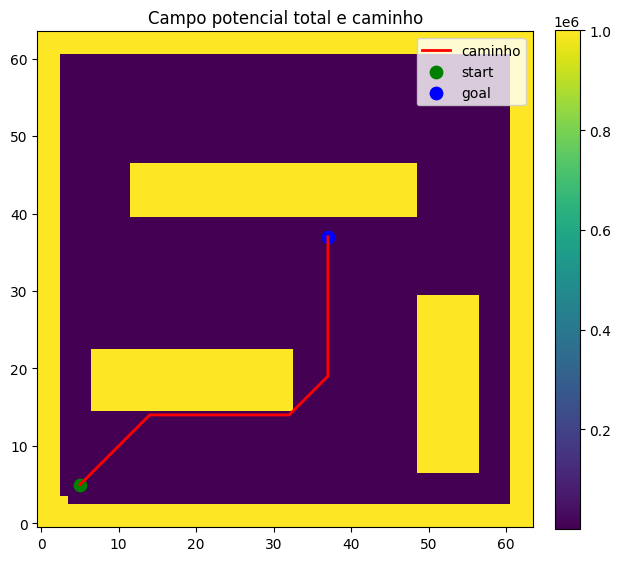

RuntimeError: Não foi possível obter handle do robô no CoppeliaSim. Erro: 1254: in sim._getObject: object does not exist, or alias/path is ill formatted.

In [ ]:
# melhor até agora (com controlador Desai et al. 1998)

import time
import numpy as np
from coppeliasim_zmqremoteapi_client import RemoteAPIClient


# ============================
# FUNÇÕES DE CAMPO POTENCIAL (melhoradas)
# ============================

def rep_force(q, obs_array, R, krep, d_min=0.05, max_f_rep=10.0):
    if obs_array is None or len(obs_array) == 0:
        return np.zeros(2)

    q = np.asarray(q).reshape(1, -1)
    obs = np.asarray(obs_array).reshape(-1, 2)
    v = q - obs
    d = np.linalg.norm(v, axis=1)
    d_safe = np.maximum(d, d_min)

    within = d < R
    if not np.any(within):
        return np.zeros(2)

    coeff = np.zeros_like(d_safe)
    coeff[within] = krep * ((1.0 / d_safe[within]) - (1.0 / R)) * (1.0 / (d_safe[within] ** 2))
    dirs = v / d_safe.reshape(-1, 1)
    rep = (coeff.reshape(-1, 1) * dirs)
    force_sum = np.sum(rep, axis=0)

    idx_closest = np.argmin(d_safe)
    dir_closest = dirs[idx_closest]
    tangential = np.array([-dir_closest[1], dir_closest[0]])
    tangential_gain = 0.4
    tangential_component = tangential_gain * tangential * min(1.0, np.linalg.norm(force_sum) / (max_f_rep + 1e-6))
    force_sum = force_sum + tangential_component

    norm_f = np.linalg.norm(force_sum)
    if norm_f > max_f_rep:
        force_sum = (force_sum / norm_f) * max_f_rep

    return force_sum


def att_force(q, goal, k=1.0, max_f_att=20.0):
    f = k * (np.asarray(goal) - np.asarray(q))
    norm = np.linalg.norm(f)
    if norm > max_f_att:
        f = f / norm * max_f_att
    return f


# ============================
# FUNÇÕES AUXILIARES
# ============================

def filter_valid_points(points, robot_pos, min_dist=0.05, max_dist=10.0):
    if points is None or len(points) == 0:
        return np.empty((0, 2))
    pts = np.asarray(points).reshape(-1, 2)
    d = np.linalg.norm(pts - robot_pos.reshape(1, 2), axis=1)
    mask = np.isfinite(d) & (d > min_dist) & (d < max_dist)
    return pts[mask]


def transform_laser_to_global(laser_points, posRobo_full, oriRobo):
    if laser_points is None or len(laser_points) == 0:
        return np.empty((0, 2))

    x_r, y_r, _ = posRobo_full
    theta = oriRobo[2]

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])
    pts = np.asarray(laser_points).reshape(-1, 2)
    pts_global = (R @ pts.T).T + np.array([x_r, y_r])
    return pts_global


# ============================
# DETECTAR E ESCAPAR DE PRESO
# ============================

def escape_if_stuck(robot_pos, prev_pos, stuck_timer, escape_mode, last_escape_time, sim_time, dt):
    stuck_threshold = 0.02
    stuck_time_limit = 1.2
    escape_duration = 2.0
    min_time_between_escapes = 3.0

    moved_dist = np.linalg.norm(robot_pos - prev_pos)
    if moved_dist < stuck_threshold:
        stuck_timer += dt
    else:
        stuck_timer = 0.0

    if (stuck_timer > stuck_time_limit) and (not escape_mode) and ((sim_time - last_escape_time) > min_time_between_escapes):
        escape_mode = True
        last_escape_time = sim_time
        print("[ESCAPE] Robô preso — iniciando rotina de escape")

    if escape_mode:
        if (sim_time - last_escape_time) < escape_duration:
            v = -0.15
            bias = 1.0 if ((int(last_escape_time) % 2) == 0) else -1.0
            w = bias * 0.9
        else:
            escape_mode = False
            v, w = None, None
            stuck_timer = 0.0
    else:
        v, w = None, None

    return v, w, stuck_timer, escape_mode, last_escape_time


# ============================
# PROGRAMA PRINCIPAL
# ============================

print('Program started')

client = RemoteAPIClient()
sim = client.require("sim")

ATT_GAIN = 1.0
REP_GAIN = 80.0
REP_RADIUS = 0.9
MAX_REP_FORCE = 25.0

LINEAR_GAIN = 0.25
ANGULAR_GAIN = 2.0

MAX_LINEAR_VEL = 0.8
MAX_ANGULAR_VEL = np.deg2rad(90)

GOAL_TOL = 0.20

prev_v_cmd = 0.0
v_smoothing = 0.12

try:
    sim.setStepping(True)
    sim.stopSimulation()
    time.sleep(0.5)

    robotHandle = sim.getObject('/PioneerP3DX')
    l_wheel = sim.getObject('./leftMotor')
    r_wheel = sim.getObject('./rightMotor')

    L = 0.381
    r = 0.0975

    goal_position = np.array([-3.0, 4.0])

    try:
        hokuyo_sensor = HokuyoSensorSim(sim, "/PioneerP3DX/fastHokuyo")
        has_sensor = True
    except Exception as e:
        print("Aviso: HokuyoSensorSim não encontrado; usando stub (nenhum obstáculo).", e)
        hokuyo_sensor = None
        has_sensor = False

    sim.startSimulation()

    prev_pos = np.array(sim.getObjectPosition(robotHandle, sim.handle_world)[:2])
    stuck_timer = 0.0
    escape_mode = False
    last_escape_time = -999.0
    last_sim_time = sim.getSimulationTime()

    while True:
        sim_time = sim.getSimulationTime()
        dt = sim_time - last_sim_time if sim_time - last_sim_time > 0 else 0.05
        last_sim_time = sim_time

        posRobo_full = sim.getObjectPosition(robotHandle, sim.handle_world)
        oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)
        robot_pos = np.array([posRobo_full[0], posRobo_full[1]])

        if np.linalg.norm(goal_position - robot_pos) <= GOAL_TOL:
            print("Objetivo alcançado.")
            break

        v_escape, w_escape, stuck_timer, escape_mode, last_escape_time = escape_if_stuck(
            robot_pos, prev_pos, stuck_timer, escape_mode, last_escape_time, sim_time, dt
        )

        if escape_mode and (v_escape is not None):
            v_cmd = v_escape
            w_cmd = w_escape
        else:
            if has_sensor:
                laser_data = hokuyo_sensor.getSensorData()
                laser_global = transform_laser_to_global(laser_data, posRobo_full, oriRobo)
                laser_global = filter_valid_points(laser_global, robot_pos, min_dist=0.05, max_dist=REP_RADIUS + 0.5)
            else:
                laser_global = np.empty((0, 2))

            f_att = att_force(robot_pos, goal_position, k=ATT_GAIN, max_f_att=20.0)
            f_rep = rep_force(robot_pos, laser_global, R=REP_RADIUS, krep=REP_GAIN, d_min=0.03, max_f_rep=MAX_REP_FORCE)

            f_total = f_att + f_rep
            if np.linalg.norm(f_total) < 1e-3:
                jitter = 0.05 * (np.random.rand(2) - 0.5)
                f_total = f_total + jitter

            # ============================================
            # CONTROLADOR DESAI ET AL. (1998)
            # ============================================

            xd, yd = f_total
            theta = oriRobo[2]
            d = L / 2.0  # ponto de controle no meio do eixo

            J = np.array([
                [np.cos(theta), np.sin(theta)],
                [-np.sin(theta) / d, np.cos(theta) / d]
            ])

            v_cmd, w_cmd = J @ np.array([xd, yd])

            v_cmd *= LINEAR_GAIN
            w_cmd *= ANGULAR_GAIN

            theta_d = np.arctan2(f_total[1], f_total[0])
            erro_theta = np.arctan2(np.sin(theta_d - theta), np.cos(theta_d - theta))
            if abs(erro_theta) > np.deg2rad(45):
                v_cmd *= 0.25

            v_cmd = np.clip(v_cmd, -MAX_LINEAR_VEL, MAX_LINEAR_VEL)
            w_cmd = np.clip(w_cmd, -MAX_ANGULAR_VEL, MAX_ANGULAR_VEL)

            prev_v_cmd = v_cmd

        # cinemática diferencial
        v_r = (2.0 * v_cmd + w_cmd * L) / (2.0 * r)
        v_l = (2.0 * v_cmd - w_cmd * L) / (2.0 * r)

        sim.setJointTargetVelocity(l_wheel, v_l)
        sim.setJointTargetVelocity(r_wheel, v_r)

        print(f"t={sim_time:.2f} | pos={robot_pos} | v={v_cmd:.3f}, w={np.rad2deg(w_cmd):.1f}°/s | escape={escape_mode} | stuck_t={stuck_timer:.2f}")

        prev_pos = robot_pos.copy()
        sim.step()

finally:
    try:
        sim.setJointTargetVelocity(l_wheel, 0)
        sim.setJointTargetVelocity(r_wheel, 0)
    except Exception:
        pass
    sim.stopSimulation()
    print('Simulação finalizada.')
    

🔁 Mínimo local detectado — fallback A*.
✅ Caminho encontrado usando A* (fallback).


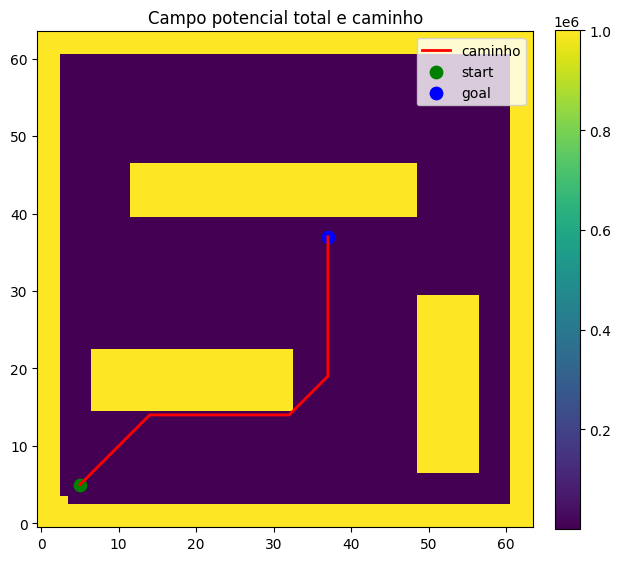

✅ Simulação iniciada e robô posicionado no ponto inicial!
🚗 Iniciando seguimento do caminho (diferencial)...
✅ Chegou ao waypoint 1/51


KeyboardInterrupt: 

In [9]:
# ============================
# Planner por Campos Potenciais + Execução (Robô Diferencial) novoooooo
# ============================

#procurar robo do professor


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
import heapq

# tenta importar client do Coppelia; se não estiver disponível, avisa mas permite testar planner offline
try:
    from coppeliasim_zmqremoteapi_client import RemoteAPIClient
    COPPELIA_AVAILABLE = True
except Exception as e:
    print("⚠️ Atenção: coppeliasim_zmqremoteapi_client não encontrado. Apenas planner será executado. Erro:", e)
    COPPELIA_AVAILABLE = False


# ============================
# Ajustes do robô diferencial (ajuste conforme seu modelo no CoppeliaSim)
# ============================
robotname = 'PioneerP3DX'   # nome do robô na cena
left_wheel_name  = f'/{robotname}/leftMotor'   # nome completo do joint (use '/' + robotname + '/jointName')
right_wheel_name = f'/{robotname}/rightMotor'  # ajuste se for diferente na sua cena
r = 0.04    # raio da roda [m]
L = 0.135   # metade da distância entre rodas [m]
max_wheel_speed = 20.0  # rad/s, limite para velocidade das rodas


# ============================
# Funções utilitárias
# ============================
def pixel_to_world(x_px, y_px, img_size=64, world_size=10):
    """
    Converte coordenadas de pixel (x_px = coluna, y_px = linha) para coordenadas do CoppeliaSim (metros).
    O centro da imagem (img_size/2, img_size/2) corresponde à origem (0,0) no mundo.
    Retorna (x_world, y_world).
    """
    scale = world_size / img_size  # metros por pixel
    x_world = (x_px - img_size / 2) * scale
    y_world = -(y_px - img_size / 2) * scale  # inverte Y porque imagem cresce para baixo
    return x_world, y_world

def Rz(theta):
    """Matriz de rotação 3x3 no plano Z."""
    return np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])


# ============================
# Carregar imagem e construir grid (64x64)
# ============================
img_path = '../mapas_meus/teste1_invertido.png'  # ajuste se necessário
img = mpimg.imread(img_path)

# inverter (já no seu código original você fazia 1 - imagem)
img = 1 - img

# limitar a dois níveis (0 e 1)
threshold = 0.5
img = img[..., 0] if img.ndim == 3 else img  # se imagem RGBA/ RGB, pega primeiro canal
img[img > threshold] = 1
img[img <= threshold] = 0

# dimensões do mapa (em células/meters) e escala
map_dims = np.array([64, 64])  # X,Y em "células"
img_h, img_w = img.shape[:2]

# escala para agrupar pixels em uma célula (caso imagem tenha maior resolução)
sy = img_h / map_dims[1]  # pixels por célula em Y (note a ordem)
sx = img_w / map_dims[0]  # pixels por célula em X

cell_size = 1  # metros por célula
rows, cols = map_dims[1], map_dims[0]  # rows=64, cols=64
grid = np.zeros((rows, cols), dtype=int)

# preencher grid: soma de pixels dentro da célula -> depois binariza
for r in range(rows):
    for c in range(cols):
        xi = int(round(c * sx))
        xf = int(round((c + 1) * sx))
        yi = int(round(r * sy))
        yf = int(round((r + 1) * sy))

        # clamp para bordas
        xi = max(0, min(img_w - 1, xi))
        xf = max(1, min(img_w, xf))
        yi = max(0, min(img_h - 1, yi))
        yf = max(1, min(img_h, yf))

        patch = img[yi:yf, xi:xf]
        if patch.size == 0:
            grid[r, c] = 0
        else:
            grid[r, c] = 1 if np.sum(patch) / patch.size > 0.5 else 0

# agora grid: 1 = ocupado, 0 = livre
grid = grid.astype(int)


# ============================
# Funções do planner por campo potencial (com fallback A*)
# ============================
def compute_distance_to_obstacles(grid):
    """Calcula distância euclidiana de cada célula até o obstáculo mais próximo."""
    rows, cols = grid.shape
    ys, xs = np.indices((rows, cols))
    obs = np.argwhere(grid == 1)
    if obs.size == 0:
        return np.full((rows, cols), np.hypot(rows, cols))
    oy = obs[:, 0][:, None, None]
    ox = obs[:, 1][:, None, None]
    dists = np.sqrt((ys[None, :, :] - oy)**2 + (xs[None, :, :] - ox)**2)
    dmin = dists.min(axis=0)
    return dmin

def potential_field_planner(grid, start, goal,
                            ka=1.0,
                            eta=300.0,
                            d0=6.0,
                            step_limit=20000,
                            visualize=True):
    """
    Monta campo potencial e obtém caminho por descida de gradiente.
    start, goal: (row, col)
    Retorna pos (dict idx -> (x_px, y_px)), path (lista de idx), U (campo potencial)
    """
    rows, cols = grid.shape
    sy, sx = np.indices((rows, cols))
    gy, gx = goal
    dist_to_goal = np.sqrt((sy - gy)**2 + (sx - gx)**2)
    U_att = 0.5 * ka * dist_to_goal**2

    dist_to_obs = compute_distance_to_obstacles(grid)
    U_rep = np.zeros_like(dist_to_obs, dtype=float)

    with np.errstate(divide='ignore', invalid='ignore'):
        mask = dist_to_obs <= d0
        U_rep[mask] = 0.5 * eta * (1.0 / (dist_to_obs[mask] + 1e-9) - 1.0 / d0)**2
        U_rep[grid == 1] = 1e6  # células ocupadas muito caras

    U = U_att + U_rep

    moves8 = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]

    cur = start
    path_coords = []
    visited = set()
    it = 0
    stuck_counter = 0
    max_stuck = 40

    while True:
        path_coords.append(cur)
        if cur == goal:
            break
        it += 1
        if it > step_limit:
            print("⚠️ Limite de iterações no gradiente excedido.")
            break

        cy, cx = cur
        cur_val = U[cy, cx]

        best = cur
        best_val = cur_val
        for dy, dx in moves8:
            ny, nx = cy + dy, cx + dx
            if 0 <= ny < rows and 0 <= nx < cols and grid[ny, nx] == 0:
                v = U[ny, nx]
                if v < best_val:
                    best_val = v
                    best = (ny, nx)

        if best == cur:
            stuck_counter += 1
            # tentativa de escape suave: escolher vizinho de menor valor (mesmo que maior que cur)
            smallest = None
            smallest_val = np.inf
            for dy, dx in moves8:
                ny, nx = cy + dy, cx + dx
                if 0 <= ny < rows and 0 <= nx < cols and grid[ny, nx] == 0:
                    v = U[ny, nx]
                    if v < smallest_val:
                        smallest_val = v
                        smallest = (ny, nx)
            if smallest is None:
                print("🚫 Start bloqueado.")
                break
            if smallest in visited or stuck_counter > max_stuck:
                print("🔁 Mínimo local detectado — fallback A*.")
                break
            cur = smallest
            visited.add(cur)
            continue
        else:
            cur = best
            visited.add(cur)

    # Se não chegou ao goal via gradiente, faz A*
    if path_coords[-1] != goal:
        def astar(grid, start, goal):
            rows, cols = grid.shape
            def h(a,b):
                return abs(a[0]-b[0]) + abs(a[1]-b[1])
            openset = []
            heapq.heappush(openset, (h(start,goal), 0, start, None))
            came_from = {}
            gscore = {start:0}
            closed = set()
            while openset:
                f, g, current, parent = heapq.heappop(openset)
                if current in closed:
                    continue
                came_from[current] = parent
                if current == goal:
                    path = []
                    cur = current
                    while cur is not None:
                        path.append(cur)
                        cur = came_from[cur]
                    return path[::-1]
                closed.add(current)
                cy, cx = current
                for dy, dx in [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]:
                    ny, nx = cy+dy, cx+dx
                    if 0 <= ny < rows and 0 <= nx < cols and grid[ny,nx] == 0:
                        ng = g + np.hypot(dy, dx)
                        if (ny,nx) not in gscore or ng < gscore[(ny,nx)]:
                            gscore[(ny,nx)] = ng
                            heapq.heappush(openset, (ng + h((ny,nx), goal), ng, (ny,nx), current))
            return None

        astar_path = astar(grid, start, goal)
        if astar_path is None:
            raise RuntimeError("A* também falhou - não foi possível achar caminho")
        path_coords = astar_path
        print("✅ Caminho encontrado usando A* (fallback).")

    # converter para pos e path no formato esperado
    pos = {}
    path = []
    for i, (r, c) in enumerate(path_coords):
        pos[i] = (int(c), int(r))   # (x_px, y_px)
        path.append(i)

    # visualização
    if visualize:
        plt.figure(figsize=(7,7))
        plt.title("Campo potencial total e caminho")
        im = plt.imshow(U, origin='upper')
        plt.colorbar(im, fraction=0.046, pad=0.04)
        ys = [p[0] for p in path_coords]
        xs = [p[1] for p in path_coords]
        plt.plot(xs, ys, '-r', linewidth=2, label='caminho')
        plt.scatter([start[1]], [start[0]], c='green', s=80, label='start')
        plt.scatter([goal[1]], [goal[0]], c='blue', s=80, label='goal')
        plt.legend()
        plt.gca().invert_yaxis()
        plt.show()

    return pos, path, U


# ============================
# Parâmetros Start / Goal (no formato row, col)
# ============================
start = (5, 5)
goal  = (37, 37)

# verificar se start/goal estão livres
if grid[start[0], start[1]] == 1:
    raise RuntimeError("Start está dentro de um obstáculo. Ajuste a posição inicial.")
if grid[goal[0], goal[1]] == 1:
    raise RuntimeError("Goal está dentro de um obstáculo. Ajuste a posição final.")

# rodar planner
pos, path, U = potential_field_planner(grid, start, goal,
                                       ka=1.0, eta=300.0, d0=6.0,
                                       step_limit=20000,
                                       visualize=True)

# ============================
# Converter pos -> pos_world (em metros) usando pixel_to_world
# ============================
pos_world = {}
for node, (x_px, y_px) in pos.items():
    pos_world[node] = pixel_to_world(x_px, y_px, img_size=64, world_size=10)


# ============================
# --- INÍCIO DA PARTE DE SIMULAÇÃO (CoppeliaSim) para robô diferencial ---
# ============================
if COPPELIA_AVAILABLE:
    client = RemoteAPIClient()
    sim = client.require("sim")

    try:
        sim.setStepping(True)
    except Exception:
        pass

    # pegar handle do robô (base)
    try:
        robotHandle = sim.getObject('/' + robotname)
    except Exception as e:
        try:
            robotHandle = sim.getObjectHandle('/' + robotname)
        except Exception as e2:
            raise RuntimeError("Não foi possível obter handle do robô no CoppeliaSim. Erros: " + str(e) + " / " + str(e2))

    # posição inicial (usar o primeiro nó do path)
    start_node = path[0]
    start_px = pos[start_node]  # (x_px, y_px) = (coluna, linha)
    start_pos_xy = pixel_to_world(start_px[0], start_px[1], img_size=64, world_size=10)
    start_pos = [start_pos_xy[0], start_pos_xy[1], 0.1]  # z pequeno
    start_ori = [0, 0, np.deg2rad(90)]  # orientação inicial (90°)

    # garantir sim parada antes de setar
    try:
        if sim.getSimulationState() != 0:
            sim.stopSimulation()
            time.sleep(1)
    except Exception:
        pass

    # setar posição e orientação
    try:
        sim.setObjectPosition(robotHandle, sim.handle_world, start_pos)
        sim.setObjectOrientation(robotHandle, sim.handle_world, start_ori)
        sim.step()
    except Exception as e:
        print("⚠️ Warning: não foi possível setar posição/orientação diretamente. Erro:", e)

    # iniciar simulação
    try:
        sim.startSimulation()
        sim.step()
    except Exception as e:
        print("⚠️ Erro iniciando simulação:", e)

    print("✅ Simulação iniciada e robô posicionado no ponto inicial!")

    # handles das rodas (left/right) - tenta getObject, senão getObjectHandle
    try:
        left_wheel  = sim.getObject(left_wheel_name)
        right_wheel = sim.getObject(right_wheel_name)
    except Exception:
        left_wheel  = sim.getObjectHandle(left_wheel_name)
        right_wheel = sim.getObjectHandle(right_wheel_name)

    # parâmetros do controlador (P simples)
    K_v = 0.6      # ganho linear (afetar velocidade)
    K_omega = 2.0  # ganho angular (afetar rotação)

    # posição inicial do simulador (ler estado)
    try:
        pos_sim = sim.getObjectPosition(robotHandle, sim.handle_world)
        ori_sim = sim.getObjectOrientation(robotHandle, sim.handle_world)
        q = np.array([pos_sim[0], pos_sim[1], ori_sim[2]])
    except Exception:
        q = np.array([start_pos[0], start_pos[1], np.deg2rad(90)])  # fallback

    # preparar waypoints (em metros)
    waypoints = [pos_world[node] for node in path]
    target_index = 0
    tolerance = 0.08  # metros

    print("🚗 Iniciando seguimento do caminho (diferencial)...")

    t0 = time.time()
    max_time = 300.0

    while target_index < len(waypoints):
        if time.time() - t0 > max_time:
            print("⏱️ Tempo máximo de execução atingido; interrompendo.")
            break

        # ler estado atual do robô (posição + orientação)
        try:
            pos_sim = sim.getObjectPosition(robotHandle, sim.handle_world)
            ori_sim = sim.getObjectOrientation(robotHandle, sim.handle_world)
            q[0], q[1], q[2] = pos_sim[0], pos_sim[1], ori_sim[2]
        except Exception:
            # se leitura falhar, manter última estimativa q
            pass

        target = np.array(waypoints[target_index])
        erro = target - q[:2]
        dist = np.linalg.norm(erro)

        angulo_desejado = np.arctan2(erro[1], erro[0])
        erro_angulo = np.arctan2(np.sin(angulo_desejado - q[2]), np.cos(angulo_desejado - q[2]))

        # controlador P (linear + angular)
        v_linear = K_v * dist
        v_angular = K_omega * erro_angulo

        # limitar velocidades
        v_linear = np.clip(v_linear, -0.4, 0.4)      # m/s
        v_angular = np.clip(v_angular, -1.5, 1.5)   # rad/s

        # converter para velocidades angulares das rodas (rad/s) - modelo diferencial
        # formulas: v = r*(w_r + w_l)/2 ; omega = r*(w_r - w_l)/(2*L)
        # => w_r = (v + omega*L) / r ; w_l = (v - omega*L) / r
        w_r = (v_linear + v_angular * L) / r
        w_l = (v_linear - v_angular * L) / r

        # limitar velocidades das rodas
        w_r = np.clip(w_r, -max_wheel_speed, max_wheel_speed)
        w_l = np.clip(w_l, -max_wheel_speed, max_wheel_speed)

        # enviar velocidades
        try:
            sim.setJointTargetVelocity(left_wheel, float(w_l))
            sim.setJointTargetVelocity(right_wheel, float(w_r))
        except Exception as e:
            print("⚠️ Erro ao setar velocidades nas rodas:", e)

        # step da sim ou sleep conforme disponibilidade
        try:
            dt = sim.getSimulationTimeStep()
        except Exception:
            dt = 0.05
        try:
            sim.step()
        except Exception:
            time.sleep(dt)

        # checar chegada ao waypoint
        if dist < tolerance:
            print(f"✅ Chegou ao waypoint {target_index+1}/{len(waypoints)}")
            target_index += 1
            # opcional: parar brevemente
            try:
                sim.setJointTargetVelocity(left_wheel, 0)
                sim.setJointTargetVelocity(right_wheel, 0)
            except:
                pass
            time.sleep(0.08)

    # parar rodas no final
    try:
        sim.setJointTargetVelocity(left_wheel, 0)
        sim.setJointTargetVelocity(right_wheel, 0)
    except:
        pass

    print("🎯 Caminho concluído! (diferencial)")

    try:
        sim.stopSimulation()
    except:
        pass

    # exibir posição final no simulador
    try:
        posf = sim.getObjectPosition(robotHandle, sim.handle_world)
        orif = sim.getObjectOrientation(robotHandle, sim.handle_world)
        print('📍 Posição final no simulador:', posf)
        print('🧭 Orientação final (rad):', orif[2])
        print('🧭 Orientação final (graus):', np.rad2deg(orif[2]))
    except:
        pass

else:
    print("⚠️ CoppeliaSim não disponível — planner executado localmente. Resultado em `pos` e `path`.")
    print("Tamanho do caminho (nós):", len(path))
    if len(path) <= 50:
        for i in path[:min(50,len(path))]:
            print(i, "->", pos[i], "-> world:", pos_world[i])
    else:
        print("Primeiros 10 nós:", [(i, pos[i]) for i in path[:10]])
        print("Últimos 10 nós:", [(i, pos[i]) for i in path[-10:]])


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque

def compute_distance_to_obstacles_fast(grid):
    """
    Distância (approx) usando BFS multi-source (distância Manhattan convertida para Euclidiana aprox).
    Evita alocação gigante com broadcasting.
    Retorna um array float de mesmas dimensões com distâncias.
    """
    rows, cols = grid.shape
    INF = 10**6
    dist = np.full((rows, cols), INF, dtype=float)
    q = deque()
    # inicializa fontes (obstáculos)
    for y in range(rows):
        for x in range(cols):
            if grid[y, x] == 1:
                dist[y, x] = 0.0
                q.append((y, x))
    # bfs (propaga dist em chebyshev/Manhattan) - pós-processaremos aproximando para euclidiana
    while q:
        y, x = q.popleft()
        d0 = dist[y, x]
        for dy, dx in [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]:
            ny, nx = y+dy, x+dx
            if 0 <= ny < rows and 0 <= nx < cols:
                nd = d0 + np.hypot(dy, dx)
                if nd < dist[ny, nx]:
                    dist[ny, nx] = nd
                    q.append((ny, nx))
    return dist

def simplify_path(path_coords):
    """
    Remove pontos redundantes da trajetória discreta por atalho: se a reta entre i e j
    não cruza obstáculo, remove intermediários.
    path_coords: lista de (row,col)
    """
    def line_clear(a,b,grid):
        # Bresenham integer line test
        y0,x0 = a; y1,x1 = b
        dy = abs(y1-y0); dx = abs(x1-x0)
        sy = 1 if y0 < y1 else -1
        sx = 1 if x0 < x1 else -1
        err = dx - dy
        y, x = y0, x0
        while True:
            if grid[y,x] == 1:
                return False
            if (y,x) == (y1,x1):
                break
            e2 = 2*err
            if e2 > -dy:
                err -= dy
                x += sx
            if e2 < dx:
                err += dx
                y += sy
        return True

    # greedy shortcutting
    new_path = []
    i = 0
    N = len(path_coords)
    while i < N:
        new_path.append(path_coords[i])
        # try farthest j such that line i->j is clear
        j = N-1
        while j > i+1:
            if line_clear(path_coords[i], path_coords[j], grid):
                break
            j -= 1
        i = j
    return new_path

def potential_field_planner(grid, start, goal,
                            ka=1.0,
                            eta=300.0,
                            d0=6.0,
                            alpha=0.8,            # tamanho do passo na descida de gradiente (em células)
                            step_limit=20000,
                            stuck_perturb_max=20, # max perturb attempts at local min
                            visualize=True):
    """
    Planner por campo potencial sem fallback A*. Faz descida de gradiente contínua (interpolada)
    e tenta escapar de mínimos locais por pequenas perturbações aleatórias.
    start, goal: (row, col)
    Retorna pos (dict idx -> (x_px, y_px)), path (lista de idx), U (campo potencial)
    """
    rows, cols = grid.shape
    ys, xs = np.indices((rows, cols))
    gy, gx = goal

    # atrativo quadrático
    dist_to_goal = np.sqrt((ys - gy)**2 + (xs - gx)**2)
    U_att = 0.5 * ka * dist_to_goal**2

    # repulsivo (distância)
    dist_to_obs = compute_distance_to_obstacles_fast(grid)
    U_rep = np.zeros_like(dist_to_obs, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        mask = dist_to_obs <= d0
        U_rep[mask] = 0.5 * eta * (1.0 / (dist_to_obs[mask] + 1e-9) - 1.0 / d0)**2
    U_rep[grid == 1] = 1e6
    U = U_att + U_rep

    # precompute gradient (discrete). Use np.gradient which retorna grad em relação a axis 0 (y) e axis 1 (x)
    Uy, Ux = np.gradient(U)  # Uy = dU/drow, Ux = dU/dcol

    # estado contínuo inicial (centro da célula start)
    y = float(start[0])
    x = float(start[1])
    path_coords = []
    visited = set()
    it = 0
    stuck_attempts = 0

    while it < step_limit:
        it += 1
        # salvar discretizado
        cy, cx = int(round(y)), int(round(x))
        cy = np.clip(cy, 0, rows-1); cx = np.clip(cx, 0, cols-1)
        path_coords.append((cy, cx))
        visited.add((cy, cx))

        # condição objetivo (quando célula arredondada == goal)
        if (cy, cx) == goal:
            print("✅ Objetivo alcançado pelo campo potencial (descida).")
            break

        # interpola gradiente no ponto (bilinear)
        # limites
        x0 = int(np.floor(x)); x1 = min(x0+1, cols-1)
        y0 = int(np.floor(y)); y1 = min(y0+1, rows-1)
        sx = x - x0; sy = y - y0

        # valores Uy/Ux nos 4 cantos
        def bilinear(arr):
            v00 = arr[y0, x0]; v10 = arr[y1, x0]; v01 = arr[y0, x1]; v11 = arr[y1, x1]
            return (1-sx)*(1-sy)*v00 + (1-sx)*sy*v10 + sx*(1-sy)*v01 + sx*sy*v11

        gy_c = bilinear(Uy)
        gx_c = bilinear(Ux)

        # passo descendente (move contra gradiente)
        ny = y - alpha * gy_c
        nx = x - alpha * gx_c

        # proteger contra sair do mapa ou entrar em célula ocupada (project back)
        ny = np.clip(ny, 0, rows-1)
        nx = np.clip(nx, 0, cols-1)
        if grid[int(round(ny)), int(round(nx))] == 1:
            # tenta projetar para vizinhança livre mais próxima (busca local)
            found = False
            for r_off in range(1,4):
                for dy in range(-r_off, r_off+1):
                    for dx in range(-r_off, r_off+1):
                        ry = int(round(ny)) + dy; rx = int(round(nx)) + dx
                        if 0 <= ry < rows and 0 <= rx < cols and grid[ry, rx] == 0:
                            ny, nx = ry, rx
                            found = True
                            break
                    if found: break
                if found: break
            if not found:
                # não há vizinhança livre — aplica perturbação
                ny = y + (random.random()-0.5)*2.0
                nx = x + (random.random()-0.5)*2.0

        # se não avançou significativamente (provável mínimo local), tenta perturbação aleatória
        if np.hypot(ny-y, nx-x) < 1e-3:
            stuck_attempts += 1
            if stuck_attempts > stuck_perturb_max:
                # tenta pequena perturbação crescente
                mag = 0.5 + 0.3 * (stuck_attempts - stuck_perturb_max)
                ny = y + (random.random()-0.5) * mag
                nx = x + (random.random()-0.5) * mag
            else:
                ny = y + (random.random()-0.5) * 0.3
                nx = x + (random.random()-0.5) * 0.3
        else:
            # reduza contador se estiver progredindo
            stuck_attempts = max(0, stuck_attempts-1)

        y, x = ny, nx

    else:
        print("⚠️ step_limit atingido sem alcançar goal. Resultado parcial retornado.")

    # compactar path_coords: manter sequência única (remover repetições consecutivas)
    compressed = []
    last = None
    for p in path_coords:
        if p != last:
            compressed.append(p)
            last = p

    # simplificar por atalho (pode usar grid global)
    try:
        simplified = simplify_path(compressed)
    except Exception:
        simplified = compressed

    # construir pos, path
    pos = {}
    path = []
    for i,(r,c) in enumerate(simplified):
        pos[i] = (int(c), int(r))   # (x_px, y_px) - col, row
        path.append(i)

    if visualize:
        plt.figure(figsize=(7,7))
        plt.title("Campo potencial (U) e caminho por descida contínua")
        im = plt.imshow(U, origin='upper')
        plt.colorbar(im, fraction=0.046, pad=0.04)
        ys = [p[0] for p in simplified]
        xs = [p[1] for p in simplified]
        plt.plot(xs, ys, '-r', linewidth=2, label='caminho (simplificado)')
        plt.scatter([start[1]], [start[0]], c='green', s=80, label='start')
        plt.scatter([goal[1]], [goal[0]], c='blue', s=80, label='goal')
        plt.legend()
        plt.gca().invert_yaxis()
        plt.show()

    return pos, path, U


In [ ]:
print(path)
print(G)
print(pos)
print(grid)

[(5, 5), (6, 5), (7, 5), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (14, 6), (14, 7), (14, 8), (14, 9), (14, 10), (14, 11), (14, 12), (14, 13), (14, 14), (14, 15), (14, 16), (14, 17), (14, 18), (14, 19), (14, 20), (14, 21), (14, 22), (14, 23), (14, 24), (14, 25), (14, 26), (14, 27), (14, 28), (14, 29), (14, 30), (14, 31), (14, 32), (14, 33), (15, 33), (16, 33), (17, 33), (18, 33), (18, 34), (18, 35), (18, 36), (18, 37), (19, 37), (20, 37), (21, 37), (22, 37), (23, 37), (24, 37), (25, 37), (26, 37), (27, 37), (28, 37), (29, 37), (30, 37), (31, 37), (32, 37), (33, 37), (34, 37), (35, 37), (36, 37), (37, 37)]


In [27]:
# ============================
# Simulação e Seguimento de Caminho no CoppeliaSim
# ============================

import numpy as np
import time
from coppeliasim_zmqremoteapi_client import RemoteAPIClient

# ============================
# Função: conversão de pixel -> mundo
# ============================
def pixel_to_world(x_px, y_px, img_size=64, world_size=10):
    """
    Converte coordenadas de pixel (imagem) para coordenadas do CoppeliaSim (em metros).
    O centro da imagem (32,32) corresponde à origem (0,0) no mundo.
    """
    scale = world_size / img_size  # metros por pixel
    x_world = (x_px - img_size / 2) * scale
    y_world = (y_px - img_size / 2) * scale  # invertido porque Y da imagem cresce para baixo
    return x_world, y_world


# ============================
# Função: matriz de rotação no plano Z
# ============================
def Rz(theta):
    """Retorna a matriz de rotação 3x3 no plano Z."""
    return np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])


# ============================
# Conectar ao CoppeliaSim
# ============================
client = RemoteAPIClient()
sim = client.require("sim")
sim.setStepping(True)

# Nome do robô
robotname = 'robotino'
robotHandle = sim.getObject('/' + robotname)

# ============================
# Conversão das posições do grafo (pixels -> mundo)
# ============================
pos_world = {}
for node, (x_px, y_px) in pos.items():
    pos_world[node] = pixel_to_world(x_px, y_px, img_size=64, world_size=10)

# ============================
# Posição inicial = primeiro nó do caminho
# ============================
start_node = path[0]
start_px = pos[start_node]
start_pos_xy = pixel_to_world(start_px[0], start_px[1], img_size=64, world_size=10)
start_pos = [start_pos_xy[0], start_pos_xy[1], 0.04]
start_ori = [0, 0, np.deg2rad(90)]  # orientação inicial (90° no plano XY)

# ============================
# Preparar simulação
# ============================
if sim.getSimulationState() != 0:
    sim.stopSimulation()
    time.sleep(1)

# Definir posição e orientação iniciais
sim.setObjectPosition(robotHandle, sim.handle_world, start_pos)
sim.setObjectOrientation(robotHandle, sim.handle_world, start_ori)
sim.step()  # aplica transformações antes de iniciar

# ============================
# Iniciar simulação
# ============================
sim.startSimulation()
sim.step()

print("✅ Simulação iniciada e robô posicionado no ponto inicial do caminho!")

# ============================
# Handles das rodas
# ============================
wheel1 = sim.getObject(f'/{robotname}/wheel0_joint')
wheel2 = sim.getObject(f'/{robotname}/wheel1_joint')
wheel3 = sim.getObject(f'/{robotname}/wheel2_joint')

# ============================
# Dados do robô
# ============================
L = 0.135   # distância do centro às rodas [m]
r = 0.040   # raio da roda [m]

# Matriz de cinemática direta (robo tipo Robotino)
Mdir = np.array([
    [-r/np.sqrt(3),     0,        r/np.sqrt(3)], 
    [r/3,            (-2*r)/3,    r/3], 
    [r/(3*L),         r/(3*L),    r/(3*L)]
])

# ============================
# Estado inicial do robô
# ============================
pos_sim = sim.getObjectPosition(robotHandle, sim.handle_world)
q = np.array([pos_sim[0], pos_sim[1], np.deg2rad(90)])  # x, y, yaw inicial

# ============================
# Configuração de controle
# ============================
waypoints = [pos_world[node] for node in path]
target_index = 0
tolerance = 0.1  # metros

print("🚗 Iniciando seguimento do caminho...")

# ============================
# Loop principal
# ============================
while target_index < len(waypoints):
    target = np.array(waypoints[target_index])
    pos_sim = sim.getObjectPosition(robotHandle, sim.handle_world)
    q[:2] = pos_sim[:2]

    # Calcular erro de posição
    erro = target - q[:2]
    dist = np.linalg.norm(erro)

    # Calcular erro angular
    angulo_desejado = np.arctan2(erro[1], erro[0])
    erro_angulo = np.arctan2(np.sin(angulo_desejado - q[2]), np.cos(angulo_desejado - q[2]))

    # Controlador proporcional
    v_linear = 0.4 * dist
    v_angular = 1.5 * erro_angulo

    # Limitar velocidades
    v_linear = np.clip(v_linear, -0.3, 0.3)
    v_angular = np.clip(v_angular, -1.0, 1.0)

    # Cinemática inversa
    qdot = np.array([v_linear * np.cos(q[2]), v_linear * np.sin(q[2]), v_angular])
    Minv = np.linalg.inv(Rz(q[2]) @ Mdir)
    u = Minv @ qdot

    # Enviar velocidades
    sim.setJointTargetVelocity(wheel1, u[0])
    sim.setJointTargetVelocity(wheel2, u[1])
    sim.setJointTargetVelocity(wheel3, u[2])

    # Atualizar posição estimada
    dt = sim.getSimulationTimeStep()
    q = q + (Rz(q[2]) @ Mdir @ u) * dt

    sim.step()

    # Verificar chegada
    if dist < tolerance:
        print(f"✅ Chegou em {path[target_index]} → indo para o próximo ponto")
        target_index += 1

# ============================
# Finalização
# ============================
# Parar o robô
for w in [wheel1, wheel2, wheel3]:
    sim.setJointTargetVelocity(w, 0)

print("🎯 Caminho concluído!")
sim.stopSimulation()

# Exibir posição final
pos = sim.getObjectPosition(robotHandle, sim.handle_world)
ori = sim.getObjectOrientation(robotHandle, sim.handle_world)
print('📍 Posição final no simulador:', pos)
print('🧭 Orientação final (graus):', np.rad2deg(ori))
print('🏁 Programa finalizado!')


✅ Simulação iniciada e robô posicionado no ponto inicial do caminho!
🚗 Iniciando seguimento do caminho...
✅ Chegou em (5, 5) → indo para o próximo ponto
✅ Chegou em (6, 5) → indo para o próximo ponto
✅ Chegou em (7, 5) → indo para o próximo ponto
✅ Chegou em (8, 5) → indo para o próximo ponto
✅ Chegou em (9, 5) → indo para o próximo ponto
✅ Chegou em (10, 5) → indo para o próximo ponto
✅ Chegou em (11, 5) → indo para o próximo ponto
✅ Chegou em (12, 5) → indo para o próximo ponto
✅ Chegou em (13, 5) → indo para o próximo ponto
✅ Chegou em (14, 5) → indo para o próximo ponto
✅ Chegou em (14, 6) → indo para o próximo ponto
✅ Chegou em (14, 7) → indo para o próximo ponto
✅ Chegou em (14, 8) → indo para o próximo ponto
✅ Chegou em (14, 9) → indo para o próximo ponto
✅ Chegou em (14, 10) → indo para o próximo ponto


KeyboardInterrupt: 